
[1] Scaling (p = 0.05/n)
  n=10, p=0.0050 ... 30/30, mean evals=326, 0.1s
  n=15, p=0.0033 ... 30/30, mean evals=758, 0.1s
  n=20, p=0.0025 ... 30/30, mean evals=1544, 0.2s
  n=30, p=0.0017 ... 30/30, mean evals=3328, 0.4s
  n=40, p=0.0013 ... 30/30, mean evals=7335, 0.8s
  n=50, p=0.0010 ... 30/30, mean evals=12055, 1.2s
  n=60, p=0.0008 ... 30/30, mean evals=17330, 1.7s
  n=80, p=0.0006 ... 30/30, mean evals=34714, 3.4s


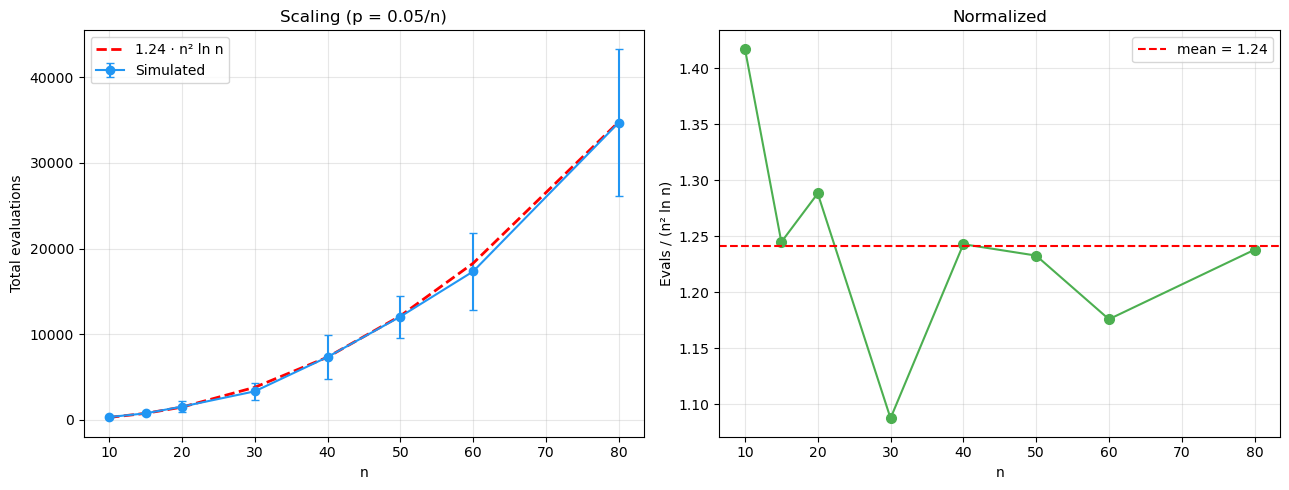


[2] Noise threshold (n=30)
  p=0.00000 ... 30/30, mean evals=3653, 0.4s
  p=0.00100 ... 30/30, mean evals=3879, 0.4s
  p=0.00500 ... 30/30, mean evals=3952, 0.4s
  p=0.01000 ... 30/30, mean evals=3241, 0.3s
  p=0.02000 ... 30/30, mean evals=3536, 0.4s
  p=0.03000 ... 30/30, mean evals=3982, 0.4s
  p=0.05000 ... 30/30, mean evals=4284, 0.5s
  p=0.08000 ... 30/30, mean evals=4097, 0.4s
  p=0.10000 ... 30/30, mean evals=3963, 0.4s
  p=0.15000 ... 30/30, mean evals=4493, 0.5s
  p=0.20000 ... 30/30, mean evals=4400, 0.5s
  p=0.30000 ... 30/30, mean evals=5009, 0.6s


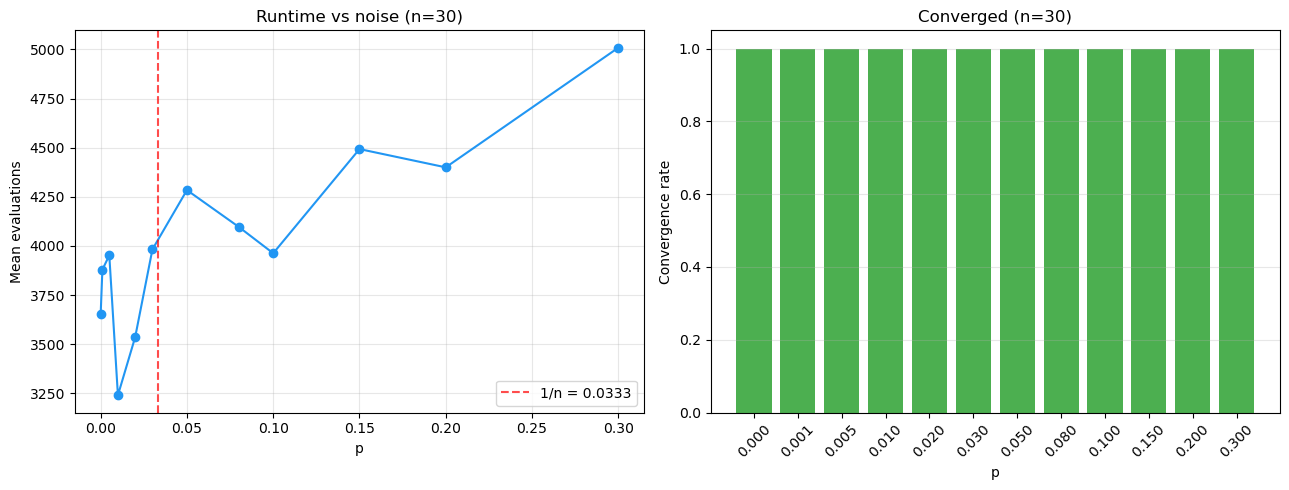


[3] Per-subproblem (n=80)


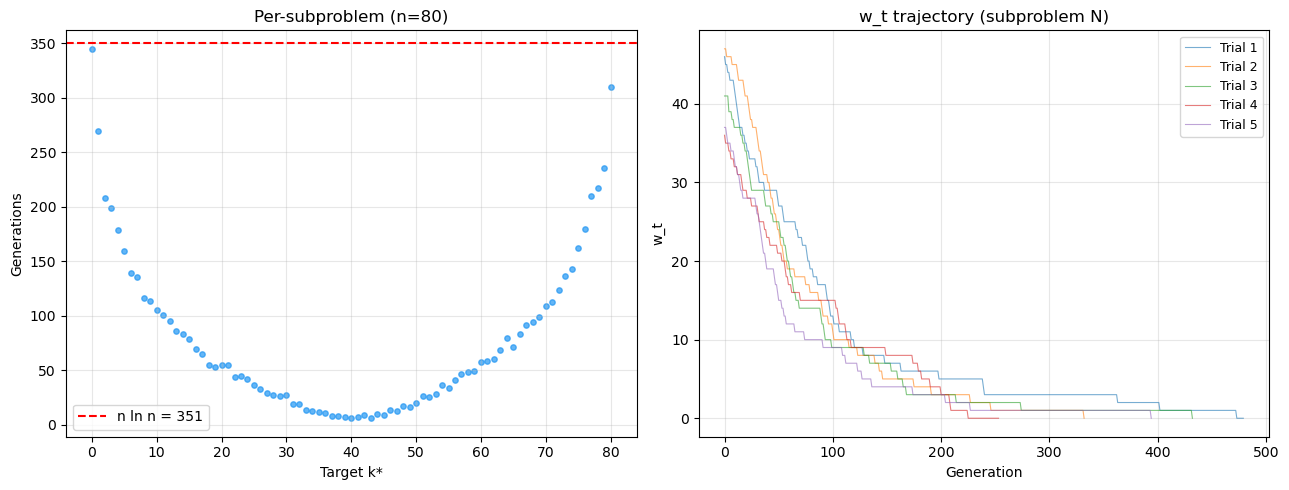


  n   evals    n²ln(n)  ratio
  10      326       230   1.42
  15      758       609   1.24
  20     1544      1198   1.29
  30     3328      3061   1.09
  40     7335      5902   1.24
  50    12055      9780   1.23
  60    17330     14740   1.18
  80    34714     28045   1.24


In [3]:
"""
Simulation of MOEA/D with T=1 on OneMinMax under one-bit prior noise.

Empirically verifies:
  1. Per-subproblem convergence in O(n log n) generations
  2. Full Pareto front coverage in O(n^2 log n) evaluations
  3. Noise tolerance threshold p <= alpha/n
  4. Stored value w_t is nonincreasing
"""

import numpy as np
import matplotlib.pyplot as plt
import time


def noisy_f(x, p, rng):
    k = int(np.sum(x))
    n = len(x)
    if rng.random() < p:
        j = rng.integers(n)
        return k - 1 if x[j] == 1 else k + 1
    return k


def tchebycheff(f_val, n, i, N):
    if N == 0:
        return n - f_val
    return max((i / N) * f_val, ((N - i) / N) * (n - f_val))


def noisy_tchebycheff(x, n, i, N, p, rng):
    nf = noisy_f(x, p, rng)
    return tchebycheff(nf, n, i, N), nf


def g_optimum_f_value(i, N, n):
    if N == 0:
        return 0
    return round((N - i) * n / N)


def simulate_moead_t1(n, N, p, max_gens=None, rng=None, track_details=False):
    if rng is None:
        rng = np.random.default_rng()
    if max_gens is None:
        max_gens = int(20 * n**2 * np.log(n + 1)) // (N + 1) + 1

    pop = [rng.integers(0, 2, size=n) for _ in range(N + 1)]
    stored_w = np.zeros(N + 1)
    for i in range(N + 1):
        stored_w[i], _ = noisy_tchebycheff(pop[i], n, i, N, p, rng)

    targets = [g_optimum_f_value(i, N, n) for i in range(N + 1)]
    covered = {int(np.sum(pop[i])) for i in range(N + 1)}

    sub_conv_gen = [None] * (N + 1)
    for i in range(N + 1):
        if int(np.sum(pop[i])) == targets[i]:
            sub_conv_gen[i] = 0

    w_history = [stored_w[N]] if track_details else None
    total_evals = N + 1

    for gen in range(1, max_gens + 1):
        for i in range(N + 1):
            y = pop[i].copy()
            y[rng.integers(n)] ^= 1

            v, _ = noisy_tchebycheff(y, n, i, N, p, rng)
            total_evals += 1

            if v <= stored_w[i]:
                pop[i] = y
                stored_w[i] = v
                true_f = int(np.sum(y))
                covered.add(true_f)
                if sub_conv_gen[i] is None and true_f == targets[i]:
                    sub_conv_gen[i] = gen

        if track_details:
            w_history.append(stored_w[N])

        if len(covered) == n + 1:
            r = {'total_evals': total_evals, 'total_gens': gen, 'converged': True}
            if track_details:
                r['sub_conv_gens'] = sub_conv_gen
                r['w_history'] = w_history
            return r

    r = {'total_evals': total_evals, 'total_gens': max_gens,
         'converged': False, 'covered_count': len(covered)}
    if track_details:
        r['sub_conv_gens'] = sub_conv_gen
        r['w_history'] = w_history
    return r


# ── Experiments ──

def run_scaling(ns, p_factor, trials=30, seed=42):
    rng = np.random.default_rng(seed)
    results = {}
    for n in ns:
        p = p_factor / n
        evals_list, gens_list, conv = [], [], 0
        print(f"  n={n}, p={p:.4f} ... ", end="", flush=True)
        t0 = time.time()
        for _ in range(trials):
            r = simulate_moead_t1(n, n, p, rng=rng)
            if r['converged']:
                evals_list.append(r['total_evals'])
                gens_list.append(r['total_gens'])
                conv += 1
        print(f"{conv}/{trials}, mean evals={np.mean(evals_list):.0f}, {time.time()-t0:.1f}s")
        results[n] = {'evals': evals_list, 'gens': gens_list,
                      'converged': conv, 'trials': trials}
    return results


def run_noise(n, p_values, trials=30, seed=123):
    rng = np.random.default_rng(seed)
    results = {}
    for p in p_values:
        evals_list, conv = [], 0
        print(f"  p={p:.5f} ... ", end="", flush=True)
        t0 = time.time()
        for _ in range(trials):
            r = simulate_moead_t1(n, n, p, rng=rng)
            if r['converged']:
                evals_list.append(r['total_evals'])
                conv += 1
        print(f"{conv}/{trials}, mean evals={np.mean(evals_list):.0f}, {time.time()-t0:.1f}s")
        results[p] = {'evals': evals_list, 'converged': conv, 'trials': trials}
    return results


def run_subproblem(n, p_factor, trials=20, seed=456):
    rng = np.random.default_rng(seed)
    p = p_factor / n
    all_sg, whs = [], []
    for t in range(trials):
        r = simulate_moead_t1(n, n, p, rng=rng, track_details=True)
        if r['converged']:
            all_sg.append(r['sub_conv_gens'])
            if t < 5:
                whs.append(r['w_history'])
    return all_sg, whs


# ── Plotting ──

def plot_scaling(results, p_factor):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ns = np.array(sorted(results.keys()), dtype=float)
    me = np.array([np.mean(results[int(n)]['evals']) if results[int(n)]['evals']
                   else np.nan for n in ns])
    se = np.array([np.std(results[int(n)]['evals']) if results[int(n)]['evals']
                   else 0 for n in ns])
    th = ns**2 * np.log(ns)
    v = ~np.isnan(me)

    axes[0].errorbar(ns, me, yerr=se, fmt='o-', color='#2196F3', capsize=3, label='Simulated')
    if np.any(v):
        c = np.nanmean(me[v] / th[v])
        axes[0].plot(ns, c * th, 'r--', lw=2, label=f'{c:.2f} · n² ln n')
    axes[0].set(xlabel='n', ylabel='Total evaluations', title=f'Scaling (p = {p_factor}/n)')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(ns[v], (me / th)[v], 'o-', color='#4CAF50', markersize=7)
    if np.any(v):
        axes[1].axhline(np.nanmean((me/th)[v]), color='r', ls='--',
                         label=f'mean = {np.nanmean((me/th)[v]):.2f}')
    axes[1].set(xlabel='n', ylabel='Evals / (n² ln n)', title='Normalized')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


def plot_noise(results, n):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    ps = np.array(sorted(results.keys()))
    me = np.array([np.mean(results[p]['evals']) if results[p]['evals']
                   else np.nan for p in ps])
    cr = np.array([results[p]['converged'] / results[p]['trials'] for p in ps])
    v = ~np.isnan(me)

    axes[0].plot(ps[v], me[v], 'o-', color='#2196F3', markersize=6)
    axes[0].axvline(1/n, color='red', ls='--', alpha=0.7, label=f'1/n = {1/n:.4f}')
    axes[0].set(xlabel='p', ylabel='Mean evaluations', title=f'Runtime vs noise (n={n})')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    cols = ['#4CAF50' if c > .8 else '#FFC107' if c > .3 else '#F44336' for c in cr]
    axes[1].bar(range(len(ps)), cr, tick_label=[f'{p:.3f}' for p in ps], color=cols)
    axes[1].set(xlabel='p', ylabel='Convergence rate', title=f'Converged (n={n})')
    plt.xticks(rotation=45); axes[1].grid(True, alpha=0.3, axis='y')
    plt.tight_layout(); plt.show()


def plot_subproblem(all_sg, whs, n, p_factor):
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    if all_sg:
        N = len(all_sg[0]) - 1
        mean_g = np.zeros(N + 1); cnt = np.zeros(N + 1)
        for sg in all_sg:
            for i in range(N + 1):
                if sg[i] is not None:
                    mean_g[i] += sg[i]; cnt[i] += 1
        ok = cnt > 0; mean_g[ok] /= cnt[ok]
        tgts = [g_optimum_f_value(i, N, n) for i in range(N + 1)]
        axes[0].scatter(tgts, mean_g, s=15, alpha=0.7, color='#2196F3')
        axes[0].axhline(n * np.log(n), color='red', ls='--', label=f'n ln n = {n*np.log(n):.0f}')
    axes[0].set(xlabel='Target k*', ylabel='Generations', title=f'Per-subproblem (n={n})')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    for idx, wh in enumerate(whs[:5]):
        axes[1].plot(wh, alpha=0.6, lw=0.8, label=f'Trial {idx+1}')
    axes[1].set(xlabel='Generation', ylabel='w_t', title='w_t trajectory (subproblem N)')
    axes[1].legend(fontsize=9); axes[1].grid(True, alpha=0.3)
    plt.tight_layout(); plt.show()


# ── Main ──

if __name__ == "__main__":
    p_factor = 0.05
    ns = [10, 15, 20, 30, 40, 50, 60, 80]

    print("\n[1] Scaling (p = 0.05/n)")
    sc = run_scaling(ns, p_factor)
    plot_scaling(sc, p_factor)

    print("\n[2] Noise threshold (n=30)")
    n_noise = 30
    ps = [0.0, 0.001, 0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.1, 0.15, 0.2, 0.3]
    nr = run_noise(n_noise, ps)
    plot_noise(nr, n_noise)

    print(f"\n[3] Per-subproblem (n={ns[-1]})")
    sg, wh = run_subproblem(ns[-1], p_factor)
    plot_subproblem(sg, wh, ns[-1], p_factor)

    print("\n  n   evals    n²ln(n)  ratio")
    for n in ns:
        ev = sc[n]['evals']
        if ev:
            me = np.mean(ev); th = n**2 * np.log(n)
            print(f"{n:>4} {me:>8.0f} {th:>9.0f} {me/th:>6.2f}")

MOEA/D T=1 vs T=2: OneMinMax under One-Bit Noise

[1] Scaling with T=1
  T=1, n= 10, p=0.0050 ... 30/30 conv, mean=326, 0.1s
  T=1, n= 15, p=0.0033 ... 30/30 conv, mean=758, 0.1s
  T=1, n= 20, p=0.0025 ... 30/30 conv, mean=1544, 0.2s
  T=1, n= 30, p=0.0017 ... 30/30 conv, mean=3328, 0.5s
  T=1, n= 40, p=0.0013 ... 30/30 conv, mean=7335, 1.0s
  T=1, n= 50, p=0.0010 ... 30/30 conv, mean=12055, 1.7s
  T=1, n= 60, p=0.0008 ... 30/30 conv, mean=17330, 2.4s
  T=1, n= 80, p=0.0006 ... 30/30 conv, mean=34714, 4.8s

[2] Scaling with T=2
  T=2, n= 10, p=0.0050 ... 30/30 conv, mean=160, 0.1s
  T=2, n= 15, p=0.0033 ... 30/30 conv, mean=396, 0.1s
  T=2, n= 20, p=0.0025 ... 30/30 conv, mean=614, 0.2s
  T=2, n= 30, p=0.0017 ... 30/30 conv, mean=1404, 0.4s
  T=2, n= 40, p=0.0013 ... 30/30 conv, mean=3370, 0.9s
  T=2, n= 50, p=0.0010 ... 30/30 conv, mean=4870, 1.4s
  T=2, n= 60, p=0.0008 ... 30/30 conv, mean=7308, 2.3s
  T=2, n= 80, p=0.0006 ... 30/30 conv, mean=11370, 3.2s


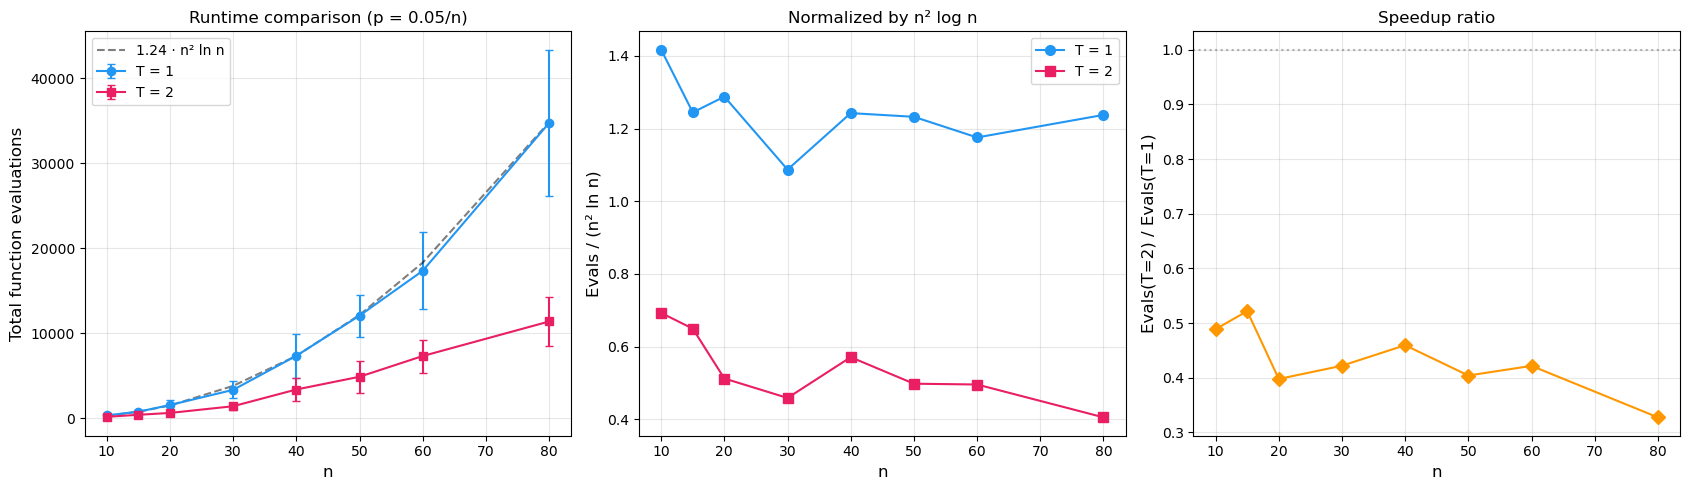


[3] Noise sweep, n=30
  p=0.0000 ... T=1: 30/30, T=2: 30/30
  p=0.0050 ... T=1: 30/30, T=2: 30/30
  p=0.0100 ... T=1: 30/30, T=2: 30/30
  p=0.0200 ... T=1: 30/30, T=2: 30/30
  p=0.0300 ... T=1: 30/30, T=2: 30/30
  p=0.0500 ... T=1: 30/30, T=2: 30/30
  p=0.1000 ... T=1: 30/30, T=2: 30/30
  p=0.1500 ... T=1: 30/30, T=2: 30/30
  p=0.2000 ... T=1: 30/30, T=2: 30/30
  p=0.3000 ... T=1: 30/30, T=2: 30/30


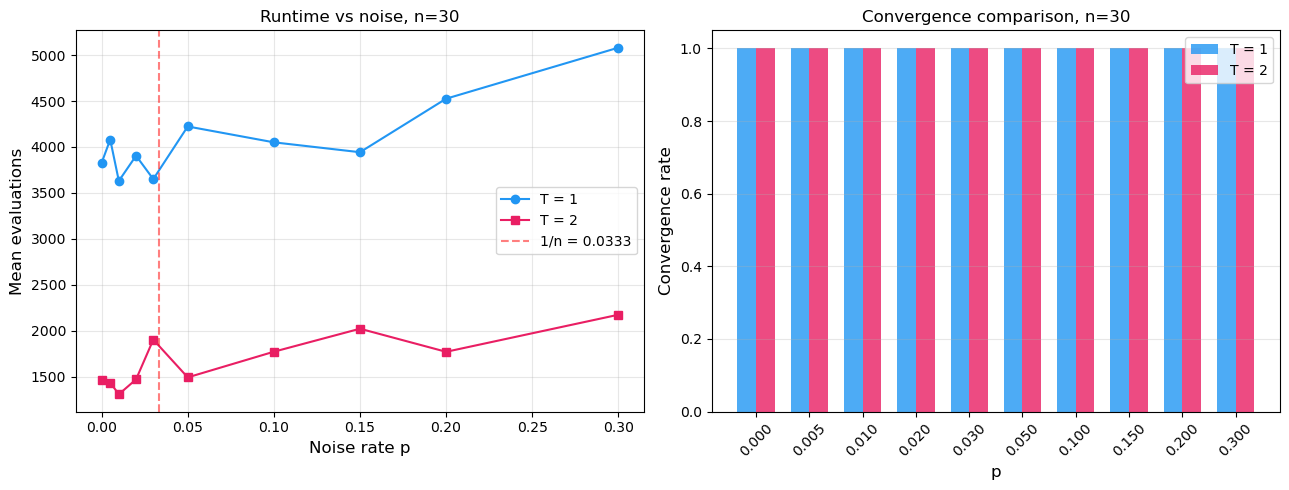


   n  T=1 evals  T=2 evals    n²ln(n)  T1/theory  T2/theory   T2/T1
-----------------------------------------------------------------
  10        326        160        230       1.42       0.69   0.489
  15        758        396        609       1.24       0.65   0.522
  20       1544        614       1198       1.29       0.51   0.398
  30       3328       1404       3061       1.09       0.46   0.422
  40       7335       3370       5902       1.24       0.57   0.459
  50      12055       4870       9780       1.23       0.50   0.404
  60      17330       7308      14740       1.18       0.50   0.422
  80      34714      11370      28045       1.24       0.41   0.328


In [5]:
"""
MOEA/D T=1 vs T=2 on OneMinMax under one-bit prior noise.
Compares runtimes against O(n^2 log n).

With T=2, B(i) = {i-1, i, i+1} (clamped), so an offspring can
replace the parent AND its neighbor if it improves both scalar values.
Subproblems are no longer independent.
"""

import numpy as np
import matplotlib.pyplot as plt
import time


# ──────────────────────────────────────────────────────────────
# Core
# ──────────────────────────────────────────────────────────────

def noisy_f(x, p, n, rng):
    """One-bit prior noise on f(x) = |x|_1."""
    k = int(np.sum(x))
    if rng.random() < p:
        j = rng.integers(n)
        return k - 1 if x[j] == 1 else k + 1
    return k


def tchebycheff(f_val, n, i, N):
    """g^i(x) = max{ (i/N)*f, ((N-i)/N)*(n-f) }, ideal point (0,0)."""
    if N == 0:
        return float(n - f_val)
    return max((i / N) * f_val, ((N - i) / N) * (n - f_val))


def g_optimum_f(i, N, n):
    if N == 0:
        return 0
    return round((N - i) * n / N)


def neighborhood(i, N, T):
    """B(i): T nearest weight vectors (including i itself)."""
    lo = max(0, i - (T - 1))
    hi = min(N, i + (T - 1))
    return list(range(lo, hi + 1))


def simulate_moead(n, N, p, T, max_gens=None, rng=None):
    """
    MOEA/D on OneMinMax with neighbourhood size T, one-bit noise, no reevaluation.
    Returns total function evaluations to cover the full Pareto front.
    """
    if rng is None:
        rng = np.random.default_rng()
    if max_gens is None:
        max_gens = int(30 * n**2 * np.log(n + 1)) // (N + 1) + 1

    # precompute neighborhoods
    nbrs = [neighborhood(i, N, T) for i in range(N + 1)]

    # initialize
    pop = [rng.integers(0, 2, size=n) for _ in range(N + 1)]
    stored_w = np.zeros(N + 1)
    for i in range(N + 1):
        nf = noisy_f(pop[i], p, n, rng)
        stored_w[i] = tchebycheff(nf, n, i, N)

    covered = {int(np.sum(pop[i])) for i in range(N + 1)}
    total_evals = N + 1

    for gen in range(1, max_gens + 1):
        for i in range(N + 1):
            # mutate: flip one random bit
            y = pop[i].copy()
            y[rng.integers(n)] ^= 1

            # single noisy evaluation of offspring
            nf_y = noisy_f(y, p, n, rng)
            total_evals += 1

            # try to replace each neighbor
            for j in nbrs[i]:
                v_j = tchebycheff(nf_y, n, j, N)
                if v_j <= stored_w[j]:
                    pop[j] = y.copy()
                    stored_w[j] = v_j
                    covered.add(int(np.sum(y)))

            # also track true f of current solutions
            for j in nbrs[i]:
                covered.add(int(np.sum(pop[j])))

        if len(covered) == n + 1:
            return {'evals': total_evals, 'gens': gen, 'converged': True}

    return {'evals': total_evals, 'gens': max_gens, 'converged': False,
            'covered': len(covered)}


# ──────────────────────────────────────────────────────────────
# Experiments
# ──────────────────────────────────────────────────────────────

def run_experiment(ns, p_factor, T, trials=30, seed=42):
    rng = np.random.default_rng(seed)
    results = {}
    for n in ns:
        p = p_factor / n
        evals_list = []
        conv = 0
        print(f"  T={T}, n={n:>3}, p={p:.4f} ... ", end="", flush=True)
        t0 = time.time()
        for _ in range(trials):
            r = simulate_moead(n, n, p, T, rng=rng)
            if r['converged']:
                evals_list.append(r['evals'])
                conv += 1
        me = np.mean(evals_list) if evals_list else float('nan')
        print(f"{conv}/{trials} conv, mean={me:.0f}, {time.time()-t0:.1f}s")
        results[n] = {'evals': evals_list, 'conv': conv, 'trials': trials}
    return results


# ──────────────────────────────────────────────────────────────
# Plotting
# ──────────────────────────────────────────────────────────────

def plot_comparison(res1, res2, p_factor):
    ns = np.array(sorted(res1.keys()), dtype=float)
    me1 = np.array([np.mean(res1[int(n)]['evals']) if res1[int(n)]['evals']
                    else np.nan for n in ns])
    me2 = np.array([np.mean(res2[int(n)]['evals']) if res2[int(n)]['evals']
                    else np.nan for n in ns])
    se1 = np.array([np.std(res1[int(n)]['evals']) if res1[int(n)]['evals']
                    else 0 for n in ns])
    se2 = np.array([np.std(res2[int(n)]['evals']) if res2[int(n)]['evals']
                    else 0 for n in ns])
    th = ns**2 * np.log(ns)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))

    # ── (a) Raw evaluations ──
    ax = axes[0]
    ax.errorbar(ns, me1, yerr=se1, fmt='o-', color='#2196F3', capsize=3, label='T = 1')
    ax.errorbar(ns, me2, yerr=se2, fmt='s-', color='#E91E63', capsize=3, label='T = 2')
    v1 = ~np.isnan(me1)
    if np.any(v1):
        c = np.nanmean(me1[v1] / th[v1])
        ax.plot(ns, c * th, 'k--', lw=1.5, alpha=0.5, label=f'{c:.2f} · n² ln n')
    ax.set_xlabel('n', fontsize=12)
    ax.set_ylabel('Total function evaluations', fontsize=12)
    ax.set_title(f'Runtime comparison (p = {p_factor}/n)', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # ── (b) Normalized by n^2 log n ──
    ax = axes[1]
    n1 = me1 / th
    n2 = me2 / th
    v1, v2 = ~np.isnan(n1), ~np.isnan(n2)
    ax.plot(ns[v1], n1[v1], 'o-', color='#2196F3', markersize=7, label='T = 1')
    ax.plot(ns[v2], n2[v2], 's-', color='#E91E63', markersize=7, label='T = 2')
    ax.set_xlabel('n', fontsize=12)
    ax.set_ylabel('Evals / (n² ln n)', fontsize=12)
    ax.set_title('Normalized by n² log n', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    # ── (c) Ratio T=2 / T=1 ──
    ax = axes[2]
    both = v1 & v2
    if np.any(both):
        ratio = me2[both] / me1[both]
        ax.plot(ns[both], ratio, 'D-', color='#FF9800', markersize=7)
        ax.axhline(1.0, color='gray', ls=':', alpha=0.6)
        ax.set_xlabel('n', fontsize=12)
        ax.set_ylabel('Evals(T=2) / Evals(T=1)', fontsize=12)
        ax.set_title('Speedup ratio', fontsize=12)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


def plot_noise_comparison(n, p_values, trials=30, seed=200):
    """Compare T=1 vs T=2 across noise levels for fixed n."""
    rng1 = np.random.default_rng(seed)
    rng2 = np.random.default_rng(seed)
    me1, me2, cr1, cr2 = [], [], [], []

    for p in p_values:
        e1, e2, c1, c2 = [], [], 0, 0
        print(f"  p={p:.4f} ... ", end="", flush=True)
        for _ in range(trials):
            r = simulate_moead(n, n, p, T=1, rng=rng1)
            if r['converged']:
                e1.append(r['evals']); c1 += 1
            r = simulate_moead(n, n, p, T=2, rng=rng2)
            if r['converged']:
                e2.append(r['evals']); c2 += 1
        me1.append(np.mean(e1) if e1 else np.nan)
        me2.append(np.mean(e2) if e2 else np.nan)
        cr1.append(c1 / trials)
        cr2.append(c2 / trials)
        print(f"T=1: {c1}/{trials}, T=2: {c2}/{trials}")

    ps = np.array(p_values)
    me1, me2 = np.array(me1), np.array(me2)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    ax = axes[0]
    v1, v2 = ~np.isnan(me1), ~np.isnan(me2)
    ax.plot(ps[v1], me1[v1], 'o-', color='#2196F3', label='T = 1')
    ax.plot(ps[v2], me2[v2], 's-', color='#E91E63', label='T = 2')
    ax.axvline(1 / n, color='red', ls='--', alpha=0.5, label=f'1/n = {1/n:.4f}')
    ax.set_xlabel('Noise rate p', fontsize=12)
    ax.set_ylabel('Mean evaluations', fontsize=12)
    ax.set_title(f'Runtime vs noise, n={n}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

    ax = axes[1]
    x = np.arange(len(p_values))
    w = 0.35
    ax.bar(x - w/2, cr1, w, color='#2196F3', alpha=0.8, label='T = 1')
    ax.bar(x + w/2, cr2, w, color='#E91E63', alpha=0.8, label='T = 2')
    ax.set_xticks(x)
    ax.set_xticklabels([f'{p:.3f}' for p in p_values], rotation=45)
    ax.set_xlabel('p', fontsize=12)
    ax.set_ylabel('Convergence rate', fontsize=12)
    ax.set_title(f'Convergence comparison, n={n}', fontsize=12)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 60)
    print("MOEA/D T=1 vs T=2: OneMinMax under One-Bit Noise")
    print("=" * 60)

    p_factor = 0.05
    ns = [10, 15, 20, 30, 40, 50, 60, 80]
    trials = 30

    # ── Experiment 1: scaling ──
    print("\n[1] Scaling with T=1")
    res1 = run_experiment(ns, p_factor, T=1, trials=trials, seed=42)

    print("\n[2] Scaling with T=2")
    res2 = run_experiment(ns, p_factor, T=2, trials=trials, seed=42)

    plot_comparison(res1, res2, p_factor)

    # ── Experiment 2: noise sweep ──
    print("\n[3] Noise sweep, n=30")
    ps = [0.0, 0.005, 0.01, 0.02, 0.03, 0.05, 0.1, 0.15, 0.2, 0.3]
    plot_noise_comparison(30, ps, trials=trials)

    # ── Summary ──
    print("\n" + "=" * 60)
    print(f"{'n':>4} {'T=1 evals':>10} {'T=2 evals':>10} {'n²ln(n)':>10} "
          f"{'T1/theory':>10} {'T2/theory':>10} {'T2/T1':>7}")
    print("-" * 65)
    for n in ns:
        e1 = res1[n]['evals']
        e2 = res2[n]['evals']
        th = n**2 * np.log(n)
        m1 = np.mean(e1) if e1 else float('nan')
        m2 = np.mean(e2) if e2 else float('nan')
        r1 = m1 / th if e1 else float('nan')
        r2 = m2 / th if e2 else float('nan')
        ratio = m2 / m1 if (e1 and e2) else float('nan')
        print(f"{n:>4} {m1:>10.0f} {m2:>10.0f} {th:>10.0f} "
              f"{r1:>10.2f} {r2:>10.2f} {ratio:>7.3f}")

n= 10, p=0.00500 ... front 30/30 (mean 309), aligned 30/30 (mean 356)  [0.1s]
n= 15, p=0.00333 ... front 30/30 (mean 894), aligned 30/30 (mean 802)  [0.2s]
n= 20, p=0.00250 ... front 30/30 (mean 1627), aligned 30/30 (mean 1649)  [0.4s]
n= 30, p=0.00167 ... front 30/30 (mean 3877), aligned 30/30 (mean 3661)  [0.9s]
n= 40, p=0.00125 ... front 30/30 (mean 7746), aligned 30/30 (mean 7481)  [1.8s]
n= 50, p=0.00100 ... front 30/30 (mean 12704), aligned 30/30 (mean 11370)  [2.9s]
n= 60, p=0.00083 ... front 30/30 (mean 16669), aligned 30/30 (mean 18863)  [4.0s]
n= 80, p=0.00063 ... front 30/30 (mean 34736), aligned 30/30 (mean 31568)  [7.3s]


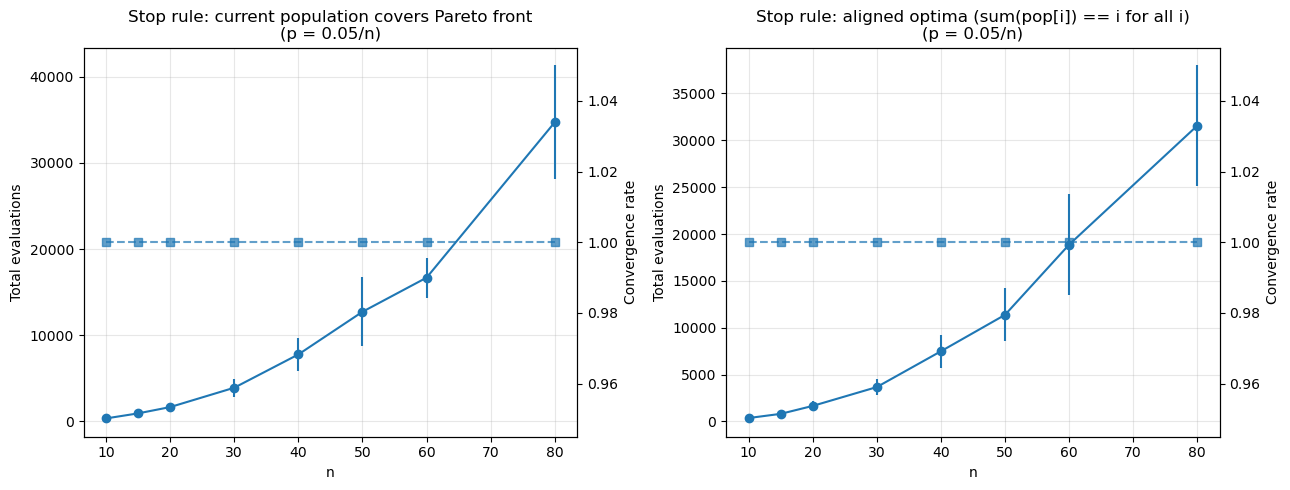

In [7]:
import numpy as np
import matplotlib.pyplot as plt
import time


# ---------- Noise model: one-bit prior noise on k = sum(x) ----------
def noisy_k(x: np.ndarray, p: float, rng: np.random.Generator) -> int:
    k = int(x.sum())
    n = x.size
    if rng.random() < p:
        j = rng.integers(n)
        return k - 1 if x[j] == 1 else k + 1
    return k


# ---------- Scalarization so that optimum for subproblem i is k=i ----------
# (i, n-i) corresponds exactly to Hamming weight k=i
def g_value_from_k(k_noisy: int, i: int) -> int:
    return abs(k_noisy - i)


def noisy_g(x: np.ndarray, i: int, p: float, rng: np.random.Generator) -> int:
    return g_value_from_k(noisy_k(x, p, rng), i)


# ---------- Stopping conditions ----------
def front_covered(pop) -> bool:
    n = pop[0].size
    weights = {int(ind.sum()) for ind in pop}
    return weights == set(range(n + 1))


def aligned_optima(pop) -> bool:
    # requires N = n so indices i correspond to target weights i
    return all(int(pop[i].sum()) == i for i in range(len(pop)))


# ---------- Simulation (T=1, neighborhood size 1 => independent (1+1)-EAs) ----------
def simulate_moead_t1(
    n: int,
    p: float,
    stop_rule: str = "front",     # "front" or "aligned"
    max_gens: int | None = None,
    rng: np.random.Generator | None = None,
):
    """
    Population size is N+1 with N=n (so indices i=0..n align with targets k=i).
    Neighborhood size 1 => subproblem i only updates itself.
    """
    if rng is None:
        rng = np.random.default_rng()

    N = n
    if max_gens is None:
        # generous cap; you can lower once you know typical times
        max_gens = int(50 * n * n * np.log(n + 2)) + 1

    pop = [rng.integers(0, 2, size=n, dtype=np.int8) for _ in range(N + 1)]
    stored_g = np.array([noisy_g(pop[i], i, p, rng) for i in range(N + 1)], dtype=int)
    total_evals = N + 1

    # initial stop check
    if stop_rule == "front" and front_covered(pop):
        return {"converged": True, "total_gens": 0, "total_evals": total_evals}
    if stop_rule == "aligned" and aligned_optima(pop):
        return {"converged": True, "total_gens": 0, "total_evals": total_evals}

    for gen in range(1, max_gens + 1):
        for i in range(N + 1):
            y = pop[i].copy()
            y[rng.integers(n)] ^= 1  # 1-bit mutation

            gy = noisy_g(y, i, p, rng)
            total_evals += 1

            if gy <= stored_g[i]:
                pop[i] = y
                stored_g[i] = gy

        if stop_rule == "front":
            if front_covered(pop):
                return {"converged": True, "total_gens": gen, "total_evals": total_evals}
        elif stop_rule == "aligned":
            if aligned_optima(pop):
                return {"converged": True, "total_gens": gen, "total_evals": total_evals}
        else:
            raise ValueError("stop_rule must be 'front' or 'aligned'.")

    return {"converged": False, "total_gens": max_gens, "total_evals": total_evals}


# ---------- Experiment runner ----------
def run_both_stops(ns, p_factor=0.05, trials=30, seed=0):
    """
    Uses p = p_factor / n.
    Returns eval lists for both stopping rules.
    """
    base = np.random.default_rng(seed)
    results = {}

    for n in ns:
        p = p_factor / n
        evals_front, evals_aligned = [], []
        conv_front = conv_aligned = 0

        print(f"n={n:>3}, p={p:.5f} ... ", end="", flush=True)
        t0 = time.time()

        for _ in range(trials):
            rng = np.random.default_rng(base.integers(2**32))

            r1 = simulate_moead_t1(n=n, p=p, stop_rule="front", rng=rng)
            if r1["converged"]:
                evals_front.append(r1["total_evals"])
                conv_front += 1

            # separate RNG stream for the aligned run (so runs are independent)
            rng2 = np.random.default_rng(base.integers(2**32))
            r2 = simulate_moead_t1(n=n, p=p, stop_rule="aligned", rng=rng2)
            if r2["converged"]:
                evals_aligned.append(r2["total_evals"])
                conv_aligned += 1

        dt = time.time() - t0
        mf = np.mean(evals_front) if evals_front else float("nan")
        ma = np.mean(evals_aligned) if evals_aligned else float("nan")
        print(f"front {conv_front}/{trials} (mean {mf:.0f}), aligned {conv_aligned}/{trials} (mean {ma:.0f})  [{dt:.1f}s]")

        results[n] = {
            "p": p,
            "front": {"evals": evals_front, "converged": conv_front, "trials": trials},
            "aligned": {"evals": evals_aligned, "converged": conv_aligned, "trials": trials},
        }

    return results


# ---------- Plotting: the two plots you want ----------
def plot_two_stops(results, p_factor):
    ns = np.array(sorted(results.keys()), dtype=float)

    def stats(kind):
        means, stds, rates = [], [], []
        for n in ns.astype(int):
            arr = results[n][kind]["evals"]
            means.append(np.mean(arr) if arr else np.nan)
            stds.append(np.std(arr) if arr else 0.0)
            rates.append(results[n][kind]["converged"] / results[n][kind]["trials"])
        return np.array(means), np.array(stds), np.array(rates)

    mean_f, std_f, rate_f = stats("front")
    mean_a, std_a, rate_a = stats("aligned")

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))

    # Plot 1: stop when front is covered
    axes[0].errorbar(ns, mean_f, yerr=std_f, fmt="o-")
    axes[0].set_title(f"Stop rule: current population covers Pareto front\n(p = {p_factor}/n)")
    axes[0].set_xlabel("n")
    axes[0].set_ylabel("Total evaluations")
    axes[0].grid(True, alpha=0.3)

    ax0b = axes[0].twinx()
    ax0b.plot(ns, rate_f, "s--", alpha=0.7)
    ax0b.set_ylabel("Convergence rate")

    # Plot 2: stop when subproblem i has true value (i, n-i) for all i
    axes[1].errorbar(ns, mean_a, yerr=std_a, fmt="o-")
    axes[1].set_title(f"Stop rule: aligned optima (sum(pop[i]) == i for all i)\n(p = {p_factor}/n)")
    axes[1].set_xlabel("n")
    axes[1].set_ylabel("Total evaluations")
    axes[1].grid(True, alpha=0.3)

    ax1b = axes[1].twinx()
    ax1b.plot(ns, rate_a, "s--", alpha=0.7)
    ax1b.set_ylabel("Convergence rate")

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    p_factor = 0.05
    ns = [10, 15, 20, 30, 40, 50, 60, 80]
    results = run_both_stops(ns, p_factor=p_factor, trials=30, seed=42)
    plot_two_stops(results, p_factor=p_factor)

MOEA/D T=1 vs T=2: two stopping criteria
  (A) Full Pareto front covered by true f-values
  (B) Every subproblem i has f(x^i) = target_i exactly

[T=1] p = 0.05/n
  T=1, n= 10, p=0.0050 ... PF 30/30 (345), OPT 30/30 (356), 0.1s
  T=1, n= 15, p=0.0033 ... PF 30/30 (758), OPT 30/30 (796), 0.1s
  T=1, n= 20, p=0.0025 ... PF 30/30 (1484), OPT 30/30 (1526), 0.2s
  T=1, n= 30, p=0.0017 ... PF 30/30 (3566), OPT 30/30 (3745), 0.5s
  T=1, n= 40, p=0.0013 ... PF 30/30 (6697), OPT 30/30 (6963), 0.9s
  T=1, n= 50, p=0.0010 ... PF 30/30 (10687), OPT 30/30 (11484), 1.5s
  T=1, n= 60, p=0.0008 ... PF 30/30 (17457), OPT 30/30 (17980), 2.4s
  T=1, n= 80, p=0.0006 ... PF 30/30 (35028), OPT 30/30 (35672), 4.5s
  T=1, n=100, p=0.0005 ... PF 30/30 (52648), OPT 30/30 (53727), 6.9s
  T=1, n=120, p=0.0004 ... PF 30/30 (83930), OPT 30/30 (85880), 12.5s
  T=1, n=140, p=0.0004 ... PF 30/30 (105887), OPT 30/30 (108320), 15.0s
  T=1, n=160, p=0.0003 ... PF 30/30 (146151), OPT 30/30 (146840), 19.9s

[T=2] p = 0.05/

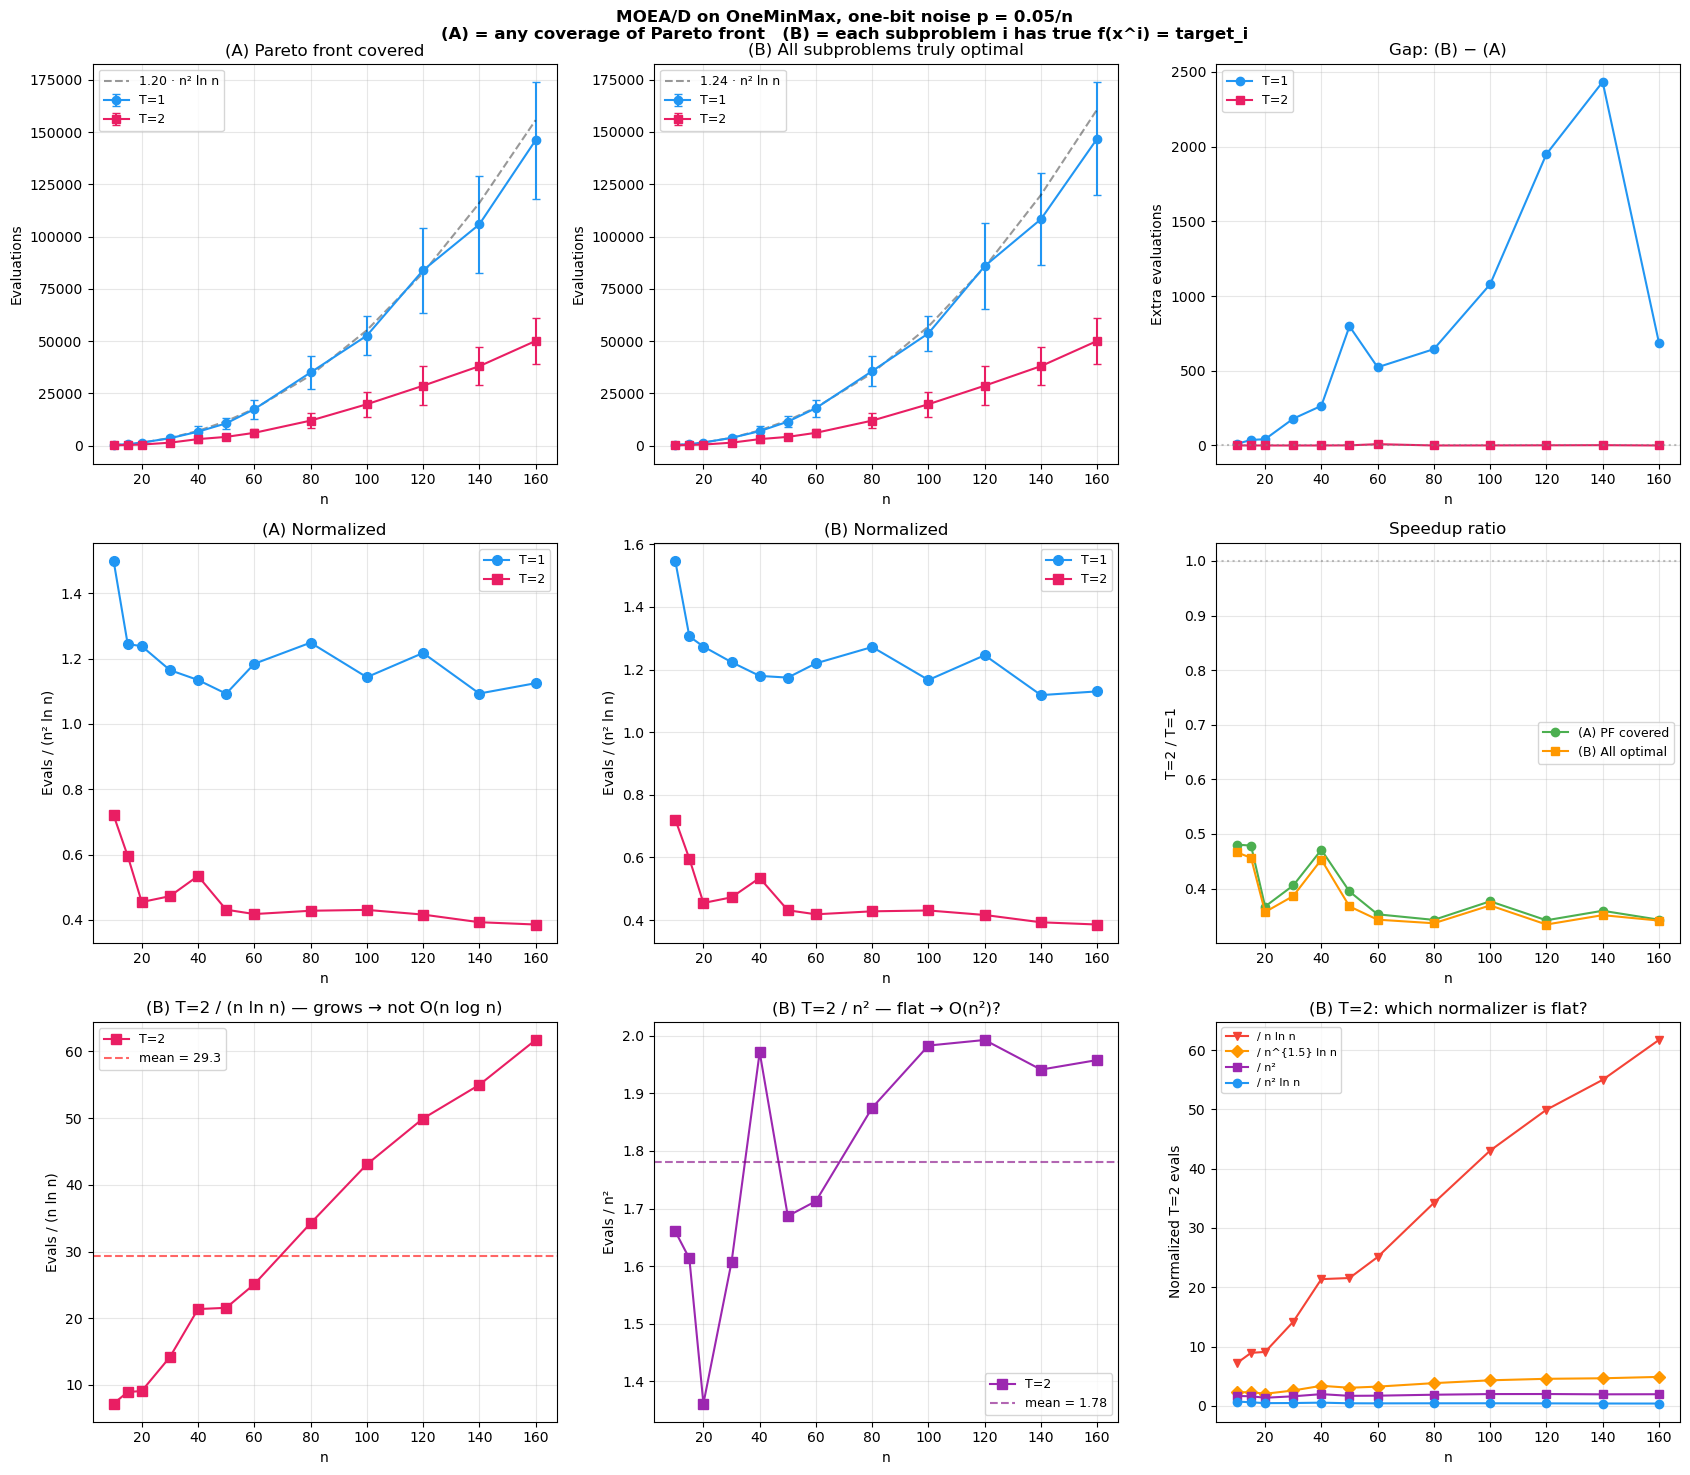


                --- T=1 ---            --- T=2 ---                          --- T=2 normalized by ---
   n  OPT evals  T1/n²ln  OPT evals   n ln n n^1.5 ln       n²  n² ln n
--------------------------------------------------------------------------------------------------------------
  10        356     1.55        166      7.2     2.28     1.66     0.72
  15        796     1.31        363      8.9     2.31     1.61     0.60
  20       1526     1.27        545      9.1     2.03     1.36     0.45
  30       3745     1.22       1446     14.2     2.59     1.61     0.47
  40       6963     1.18       3154     21.4     3.38     1.97     0.53
  50      11484     1.17       4217     21.6     3.05     1.69     0.43
  60      17980     1.22       6166     25.1     3.24     1.71     0.42
  80      35672     1.27      11999     34.2     3.83     1.87     0.43
 100      53727     1.17      19828     43.1     4.31     1.98     0.43
 120      85880     1.25      28691     49.9     4.56     1.99    

In [17]:
"""
MOEA/D T=1 vs T=2 on OneMinMax under one-bit prior noise.

Two stopping criteria:
  (A) Pareto front covered: for every k in {0,...,n}, some solution has true f-value k.
  (B) All subproblems optimal: for every i, f(x^i) = target_i exactly.
      (Stronger: noise may cause a subproblem to "think" it's optimal when it isn't.)

Plots both criteria against n^2 log n for T=1 and T=2.
"""

import numpy as np
import matplotlib.pyplot as plt
import time


def noisy_f(x, p, n, rng):
    k = int(np.sum(x))
    if rng.random() < p:
        j = rng.integers(n)
        return k - 1 if x[j] == 1 else k + 1
    return k


def tchebycheff(f_val, n, i, N):
    if N == 0:
        return float(n - f_val)
    return max((i / N) * f_val, ((N - i) / N) * (n - f_val))


def g_target(i, N, n):
    """g-optimal f-value for subproblem i.
    With ideal point (0,0), subproblem i targets f = round((N-i)*n/N).
    When N=n: target_i = n-i, so objective is (n-i, i).
    """
    if N == 0:
        return 0
    return round((N - i) * n / N)


def neighborhood(i, N, T):
    lo = max(0, i - (T - 1))
    hi = min(N, i + (T - 1))
    return list(range(lo, hi + 1))


def simulate(n, N, p, T, max_evals=None, rng=None):
    """
    Returns dict with:
      'evals_pf':  evaluations until full Pareto front is covered (or None)
      'evals_opt': evaluations until every subproblem has true f = target (or None)
      'converged_pf', 'converged_opt': booleans
    """
    if rng is None:
        rng = np.random.default_rng()
    if max_evals is None:
        max_evals = int(40 * n**2 * np.log(n + 1))

    nbrs = [neighborhood(i, N, T) for i in range(N + 1)]
    targets = [g_target(i, N, n) for i in range(N + 1)]

    # initialize
    pop = [rng.integers(0, 2, size=n) for _ in range(N + 1)]
    true_f = np.array([int(np.sum(pop[i])) for i in range(N + 1)])
    stored_w = np.zeros(N + 1)
    for i in range(N + 1):
        nf = noisy_f(pop[i], p, n, rng)
        stored_w[i] = tchebycheff(nf, n, i, N)

    # criterion A: set of covered true f-values
    covered = set(true_f)

    # criterion B: which subproblems have true f = target
    at_opt = np.array([true_f[i] == targets[i] for i in range(N + 1)])

    evals_pf = None    # evals when PF first fully covered
    evals_opt = None   # evals when all subproblems truly optimal
    total_evals = N + 1

    if len(covered) == n + 1:
        evals_pf = total_evals
    if np.all(at_opt):
        evals_opt = total_evals

    gen = 0
    while total_evals < max_evals:
        gen += 1
        for i in range(N + 1):
            y = pop[i].copy()
            y[rng.integers(n)] ^= 1
            nf_y = noisy_f(y, p, n, rng)
            total_evals += 1

            for j in nbrs[i]:
                v_j = tchebycheff(nf_y, n, j, N)
                if v_j <= stored_w[j]:
                    pop[j] = y.copy()
                    stored_w[j] = v_j
                    tf = int(np.sum(y))
                    true_f[j] = tf
                    covered.add(tf)
                    at_opt[j] = (tf == targets[j])

            # check criteria after each evaluation
            if evals_pf is None and len(covered) == n + 1:
                evals_pf = total_evals
            if evals_opt is None and np.all(at_opt):
                evals_opt = total_evals

            if evals_pf is not None and evals_opt is not None:
                return {
                    'evals_pf': evals_pf, 'evals_opt': evals_opt,
                    'converged_pf': True, 'converged_opt': True,
                }

    return {
        'evals_pf': evals_pf, 'evals_opt': evals_opt,
        'converged_pf': evals_pf is not None,
        'converged_opt': evals_opt is not None,
    }


# ──────────────────────────────────────────────────────────────
# Experiments
# ──────────────────────────────────────────────────────────────

def run(ns, p_factor, T, trials=30, seed=42):
    rng = np.random.default_rng(seed)
    results = {}
    for n in ns:
        p = p_factor / n
        pf_list, opt_list = [], []
        cpf, copt = 0, 0
        print(f"  T={T}, n={n:>3}, p={p:.4f} ... ", end="", flush=True)
        t0 = time.time()
        for _ in range(trials):
            r = simulate(n, n, p, T, rng=rng)
            if r['converged_pf']:
                pf_list.append(r['evals_pf']); cpf += 1
            if r['converged_opt']:
                opt_list.append(r['evals_opt']); copt += 1
        dt = time.time() - t0
        mpf = np.mean(pf_list) if pf_list else float('nan')
        mopt = np.mean(opt_list) if opt_list else float('nan')
        print(f"PF {cpf}/{trials} ({mpf:.0f}), OPT {copt}/{trials} ({mopt:.0f}), {dt:.1f}s")
        results[n] = {
            'pf': pf_list, 'opt': opt_list,
            'cpf': cpf, 'copt': copt, 'trials': trials
        }
    return results


# ──────────────────────────────────────────────────────────────
# Plotting
# ──────────────────────────────────────────────────────────────

def make_plots(res1, res2, p_factor):
    ns = np.array(sorted(res1.keys()), dtype=float)
    th = ns**2 * np.log(ns)

    def extract(res, key):
        me = np.array([np.mean(res[int(n)][key]) if res[int(n)][key]
                       else np.nan for n in ns])
        se = np.array([np.std(res[int(n)][key]) if res[int(n)][key]
                       else 0 for n in ns])
        return me, se

    pf1, pf1_se = extract(res1, 'pf')
    pf2, pf2_se = extract(res2, 'pf')
    opt1, opt1_se = extract(res1, 'opt')
    opt2, opt2_se = extract(res2, 'opt')

    fig, axes = plt.subplots(3, 3, figsize=(17, 15))
    th_nlogn = ns * np.log(ns)  # n ln n reference

    # ── Row 1: raw evals ──
    # (0,0) Criterion A: PF coverage
    ax = axes[0, 0]
    ax.errorbar(ns, pf1, yerr=pf1_se, fmt='o-', color='#2196F3', capsize=3, label='T=1')
    ax.errorbar(ns, pf2, yerr=pf2_se, fmt='s-', color='#E91E63', capsize=3, label='T=2')
    v = ~np.isnan(pf1)
    if np.any(v):
        c = np.nanmean(pf1[v] / th[v])
        ax.plot(ns, c * th, 'k--', lw=1.5, alpha=0.4, label=f'{c:.2f} · n² ln n')
    ax.set_xlabel('n')
    ax.set_ylabel('Evaluations')
    ax.set_title('(A) Pareto front covered')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # (0,1) Criterion B: all subproblems at true optimum
    ax = axes[0, 1]
    ax.errorbar(ns, opt1, yerr=opt1_se, fmt='o-', color='#2196F3', capsize=3, label='T=1')
    ax.errorbar(ns, opt2, yerr=opt2_se, fmt='s-', color='#E91E63', capsize=3, label='T=2')
    v = ~np.isnan(opt1)
    if np.any(v):
        c = np.nanmean(opt1[v] / th[v])
        ax.plot(ns, c * th, 'k--', lw=1.5, alpha=0.4, label=f'{c:.2f} · n² ln n')
    ax.set_xlabel('n')
    ax.set_ylabel('Evaluations')
    ax.set_title('(B) All subproblems truly optimal')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # (0,2) Gap: criterion B - criterion A
    ax = axes[0, 2]
    gap1 = opt1 - pf1
    gap2 = opt2 - pf2
    v1 = ~np.isnan(gap1)
    v2 = ~np.isnan(gap2)
    if np.any(v1):
        ax.plot(ns[v1], gap1[v1], 'o-', color='#2196F3', label='T=1')
    if np.any(v2):
        ax.plot(ns[v2], gap2[v2], 's-', color='#E91E63', label='T=2')
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('n')
    ax.set_ylabel('Extra evaluations')
    ax.set_title('Gap: (B) − (A)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Row 2: normalized ──
    # (1,0) Criterion A normalized
    ax = axes[1, 0]
    n1 = pf1 / th
    n2 = pf2 / th
    v1, v2 = ~np.isnan(n1), ~np.isnan(n2)
    ax.plot(ns[v1], n1[v1], 'o-', color='#2196F3', markersize=7, label='T=1')
    ax.plot(ns[v2], n2[v2], 's-', color='#E91E63', markersize=7, label='T=2')
    ax.set_xlabel('n')
    ax.set_ylabel('Evals / (n² ln n)')
    ax.set_title('(A) Normalized')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # (1,1) Criterion B normalized
    ax = axes[1, 1]
    n1 = opt1 / th
    n2 = opt2 / th
    v1, v2 = ~np.isnan(n1), ~np.isnan(n2)
    ax.plot(ns[v1], n1[v1], 'o-', color='#2196F3', markersize=7, label='T=1')
    ax.plot(ns[v2], n2[v2], 's-', color='#E91E63', markersize=7, label='T=2')
    ax.set_xlabel('n')
    ax.set_ylabel('Evals / (n² ln n)')
    ax.set_title('(B) Normalized')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # (1,2) Ratio T=2/T=1 for both criteria
    ax = axes[1, 2]
    both_pf = ~np.isnan(pf1) & ~np.isnan(pf2)
    both_opt = ~np.isnan(opt1) & ~np.isnan(opt2)
    if np.any(both_pf):
        ax.plot(ns[both_pf], pf2[both_pf] / pf1[both_pf],
                'o-', color='#4CAF50', label='(A) PF covered')
    if np.any(both_opt):
        ax.plot(ns[both_opt], opt2[both_opt] / opt1[both_opt],
                's-', color='#FF9800', label='(B) All optimal')
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('n')
    ax.set_ylabel('T=2 / T=1')
    ax.set_title('Speedup ratio')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # ── Row 3: T=2 normalized by different candidates ──
    # (2,0) Criterion B: T=2 / (n ln n) — should grow if not O(n log n)
    ax = axes[2, 0]
    r2a = opt2 / th_nlogn
    v2 = ~np.isnan(r2a)
    ax.plot(ns[v2], r2a[v2], 's-', color='#E91E63', markersize=7, label='T=2')
    if np.any(v2):
        ax.axhline(np.nanmean(r2a[v2]), color='r', ls='--', alpha=0.6,
                    label=f'mean = {np.nanmean(r2a[v2]):.1f}')
    ax.set_xlabel('n')
    ax.set_ylabel('Evals / (n ln n)')
    ax.set_title('(B) T=2 / (n ln n) — grows → not O(n log n)')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # (2,1) Criterion B: T=2 / n^2 — should be flat if O(n^2)
    ax = axes[2, 1]
    r2b = opt2 / (ns**2)
    v2 = ~np.isnan(r2b)
    ax.plot(ns[v2], r2b[v2], 's-', color='#9C27B0', markersize=7, label='T=2')
    if np.any(v2):
        ax.axhline(np.nanmean(r2b[v2]), color='purple', ls='--', alpha=0.6,
                    label=f'mean = {np.nanmean(r2b[v2]):.2f}')
    ax.set_xlabel('n')
    ax.set_ylabel('Evals / n²')
    ax.set_title('(B) T=2 / n² — flat → O(n²)?')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

    # (2,2) All normalizations for T=2 criterion B side by side
    ax = axes[2, 2]
    candidates = {
        'n ln n':    opt2 / th_nlogn,
        'n^{1.5} ln n': opt2 / (ns**1.5 * np.log(ns)),
        'n²':        opt2 / (ns**2),
        'n² ln n':   opt2 / th,
    }
    colors_c = ['#F44336', '#FF9800', '#9C27B0', '#2196F3']
    markers = ['v', 'D', 's', 'o']
    for (lbl, vals), col, mk in zip(candidates.items(), colors_c, markers):
        v = ~np.isnan(vals)
        ax.plot(ns[v], vals[v], f'{mk}-', color=col, markersize=6, label=f'/ {lbl}')
    ax.set_xlabel('n')
    ax.set_ylabel('Normalized T=2 evals')
    ax.set_title('(B) T=2: which normalizer is flat?')
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

    plt.suptitle(f'MOEA/D on OneMinMax, one-bit noise p = {p_factor}/n\n'
                 f'(A) = any coverage of Pareto front   '
                 f'(B) = each subproblem i has true f(x^i) = target_i',
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()


# ──────────────────────────────────────────────────────────────
# Main
# ──────────────────────────────────────────────────────────────

if __name__ == "__main__":
    print("=" * 65)
    print("MOEA/D T=1 vs T=2: two stopping criteria")
    print("  (A) Full Pareto front covered by true f-values")
    print("  (B) Every subproblem i has f(x^i) = target_i exactly")
    print("=" * 65)

    p_factor = 0.05
    ns = [10, 15, 20, 30, 40, 50, 60, 80, 100, 120, 140, 160]
    trials = 30

    print(f"\n[T=1] p = {p_factor}/n")
    res1 = run(ns, p_factor, T=1, trials=trials, seed=42)

    print(f"\n[T=2] p = {p_factor}/n")
    res2 = run(ns, p_factor, T=2, trials=trials, seed=42)

    make_plots(res1, res2, p_factor)

    # summary table
    print("\n" + "=" * 110)
    print(f"{'':>4} {'--- T=1 ---':>22} {'--- T=2 ---':>22} {'--- T=2 normalized by ---':>50}")
    print(f"{'n':>4} {'OPT evals':>10} {'T1/n²ln':>8} "
          f"{'OPT evals':>10} {'n ln n':>8} {'n^1.5 ln':>8} {'n²':>8} {'n² ln n':>8}")
    print("-" * 110)
    for n in ns:
        r1, r2 = res1[n], res2[n]
        mopt1 = np.mean(r1['opt']) if r1['opt'] else float('nan')
        mopt2 = np.mean(r2['opt']) if r2['opt'] else float('nan')
        th_n2ln = n**2 * np.log(n)
        th_nln = n * np.log(n)
        th_n15ln = n**1.5 * np.log(n)
        th_n2 = n**2
        print(f"{n:>4} {mopt1:>10.0f} {mopt1/th_n2ln:>8.2f} "
              f"{mopt2:>10.0f} {mopt2/th_nln:>8.1f} {mopt2/th_n15ln:>8.2f} "
              f"{mopt2/th_n2:>8.2f} {mopt2/th_n2ln:>8.2f}")

n= 10, p=0.00500 ... T1 front 30/30 (mean 308), T2 front 30/30 (mean 229) | T1 aligned 30/30 (mean 374), T2 aligned 30/30 (mean 221) [0.3s]
n= 15, p=0.00333 ... T1 front 30/30 (mean 830), T2 front 30/30 (mean 386) | T1 aligned 30/30 (mean 892), T2 aligned 30/30 (mean 405) [0.7s]
n= 20, p=0.00250 ... T1 front 30/30 (mean 1455), T2 front 30/30 (mean 967) | T1 aligned 30/30 (mean 1547), T2 aligned 30/30 (mean 937) [1.3s]
n= 30, p=0.00167 ... T1 front 30/30 (mean 3640), T2 front 30/30 (mean 2388) | T1 aligned 30/30 (mean 3902), T2 aligned 30/30 (mean 2336) [3.1s]
n= 40, p=0.00125 ... T1 front 30/30 (mean 6858), T2 front 30/30 (mean 4360) | T1 aligned 30/30 (mean 7638), T2 aligned 30/30 (mean 3899) [5.9s]
n= 50, p=0.00100 ... T1 front 30/30 (mean 11847), T2 front 30/30 (mean 6615) | T1 aligned 30/30 (mean 11990), T2 aligned 30/30 (mean 6606) [9.7s]
n= 60, p=0.00083 ... T1 front 30/30 (mean 17893), T2 front 30/30 (mean 10874) | T1 aligned 30/30 (mean 18298), T2 aligned 30/30 (mean 9892) [14.

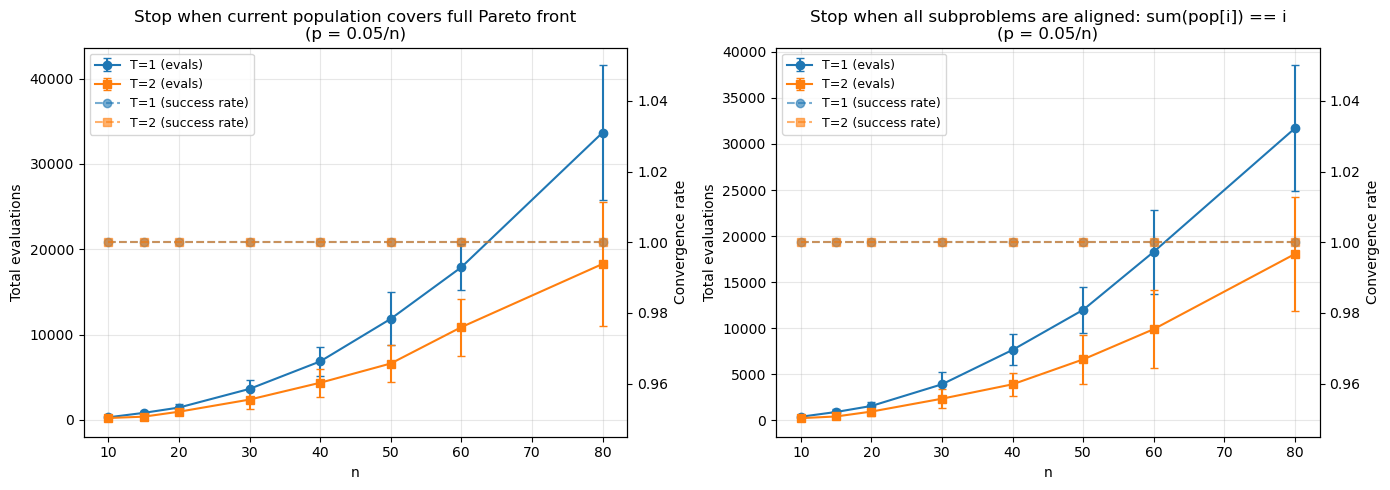

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import time


# ---------- One-bit prior noise on k = sum(x) ----------
def noisy_k(x: np.ndarray, p: float, rng: np.random.Generator) -> int:
    k = int(x.sum())
    n = x.size
    if rng.random() < p:
        j = rng.integers(n)
        return k - 1 if x[j] == 1 else k + 1
    return k


# ---------- Scalarization: optimum for subproblem i at k=i ----------
def g_from_k(k_noisy: int, i: int) -> int:
    return abs(k_noisy - i)


# ---------- Neighborhoods ----------
def build_neighborhoods(N: int, T: int):
    """
    1D weights => natural neighbors are adjacent indices.
    We build B(i) of size T including i, then add neighbors outward.
    For ties (left/right), we alternate order based on parity of i for balance.
    """
    assert 1 <= T <= N + 1
    neigh = []
    for i in range(N + 1):
        B = [i]
        step = 1
        while len(B) < T:
            cand = [(i + step), (i - step)] if (i % 2 == 0) else [(i - step), (i + step)]
            for j in cand:
                if 0 <= j <= N and j not in B:
                    B.append(j)
                    if len(B) == T:
                        break
            step += 1
        neigh.append(B)
    return neigh


# ---------- Stopping conditions (on TRUE values) ----------
def front_covered(pop) -> bool:
    n = pop[0].size
    weights = {int(ind.sum()) for ind in pop}
    return weights == set(range(n + 1))


def aligned_optima(pop) -> bool:
    # requires N=n, i.e., pop has length n+1, and target for i is weight i
    return all(int(pop[i].sum()) == i for i in range(len(pop)))


# ---------- Simulation: MOEA/D with neighborhood size T ----------
def simulate_moead(
    n: int,
    p: float,
    T: int,
    stop_rule: str,            # "front" or "aligned"
    max_gens: int | None = None,
    rng: np.random.Generator | None = None,
):
    if rng is None:
        rng = np.random.default_rng()

    N = n
    B = build_neighborhoods(N, T)

    if max_gens is None:
        max_gens = int(50 * n * n * np.log(n + 2)) + 1

    pop = [rng.integers(0, 2, size=n, dtype=np.int8) for _ in range(N + 1)]

    # store last accepted noisy scalar value per subproblem
    stored_g = np.empty(N + 1, dtype=int)
    total_evals = 0

    # initial evaluation: each subproblem evaluates its own incumbent once
    for i in range(N + 1):
        kN = noisy_k(pop[i], p, rng)
        stored_g[i] = g_from_k(kN, i)
        total_evals += 1

    # initial stop check
    if stop_rule == "front" and front_covered(pop):
        return {"converged": True, "total_gens": 0, "total_evals": total_evals}
    if stop_rule == "aligned" and aligned_optima(pop):
        return {"converged": True, "total_gens": 0, "total_evals": total_evals}

    for gen in range(1, max_gens + 1):
        for i in range(N + 1):
            # mating selection in neighborhood
            parent_idx = rng.choice(B[i])
            y = pop[parent_idx].copy()
            y[rng.integers(n)] ^= 1  # 1-bit mutation

            # evaluate ONCE (one noisy k), then reuse for all neighborhood comparisons
            kN = noisy_k(y, p, rng)
            total_evals += 1

            # neighborhood replacement
            for ell in B[i]:
                gy = g_from_k(kN, ell)
                if gy <= stored_g[ell]:
                    pop[ell] = y.copy()   # avoid aliasing across subproblems
                    stored_g[ell] = gy

        if stop_rule == "front":
            if front_covered(pop):
                return {"converged": True, "total_gens": gen, "total_evals": total_evals}
        elif stop_rule == "aligned":
            if aligned_optima(pop):
                return {"converged": True, "total_gens": gen, "total_evals": total_evals}
        else:
            raise ValueError("stop_rule must be 'front' or 'aligned'")

    return {"converged": False, "total_gens": max_gens, "total_evals": total_evals}


# ---------- Run experiments for T=1 and T=2 ----------
def run_compare_T(ns, p_factor=0.05, trials=30, seed=0):
    base = np.random.default_rng(seed)
    out = {}

    for n in ns:
        p = p_factor / n
        out[n] = {"p": p, "T1": {"front": [], "aligned": [], "front_ok": 0, "aligned_ok": 0},
                        "T2": {"front": [], "aligned": [], "front_ok": 0, "aligned_ok": 0}}

        print(f"n={n:>3}, p={p:.5f} ... ", end="", flush=True)
        t0 = time.time()

        for _ in range(trials):
            # independent streams for each run
            rng1 = np.random.default_rng(base.integers(2**32))
            r1f = simulate_moead(n, p, T=1, stop_rule="front", rng=rng1)
            if r1f["converged"]:
                out[n]["T1"]["front"].append(r1f["total_evals"])
                out[n]["T1"]["front_ok"] += 1

            rng2 = np.random.default_rng(base.integers(2**32))
            r1a = simulate_moead(n, p, T=1, stop_rule="aligned", rng=rng2)
            if r1a["converged"]:
                out[n]["T1"]["aligned"].append(r1a["total_evals"])
                out[n]["T1"]["aligned_ok"] += 1

            rng3 = np.random.default_rng(base.integers(2**32))
            r2f = simulate_moead(n, p, T=2, stop_rule="front", rng=rng3)
            if r2f["converged"]:
                out[n]["T2"]["front"].append(r2f["total_evals"])
                out[n]["T2"]["front_ok"] += 1

            rng4 = np.random.default_rng(base.integers(2**32))
            r2a = simulate_moead(n, p, T=2, stop_rule="aligned", rng=rng4)
            if r2a["converged"]:
                out[n]["T2"]["aligned"].append(r2a["total_evals"])
                out[n]["T2"]["aligned_ok"] += 1

        dt = time.time() - t0
        def m(arr): return np.mean(arr) if arr else float("nan")
        print(
            f"T1 front {out[n]['T1']['front_ok']}/{trials} (mean {m(out[n]['T1']['front']):.0f}), "
            f"T2 front {out[n]['T2']['front_ok']}/{trials} (mean {m(out[n]['T2']['front']):.0f}) | "
            f"T1 aligned {out[n]['T1']['aligned_ok']}/{trials} (mean {m(out[n]['T1']['aligned']):.0f}), "
            f"T2 aligned {out[n]['T2']['aligned_ok']}/{trials} (mean {m(out[n]['T2']['aligned']):.0f}) "
            f"[{dt:.1f}s]"
        )

    out["trials"] = trials
    out["p_factor"] = p_factor
    return out


# ---------- Plot: two panels (front vs aligned), overlay T=1 and T=2 ----------
def plot_compare_T(results):
    trials = results["trials"]
    p_factor = results["p_factor"]

    ns = np.array(sorted([k for k in results.keys() if isinstance(k, int)]), dtype=float)

    def stats(Tkey, rule):
        means, stds, rates = [], [], []
        for n in ns.astype(int):
            arr = results[n][Tkey][rule]
            means.append(np.mean(arr) if arr else np.nan)
            stds.append(np.std(arr) if arr else 0.0)
            ok = results[n][Tkey][f"{rule}_ok"] / trials
            rates.append(ok)
        return np.array(means), np.array(stds), np.array(rates)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for ax, rule, title in [
        (axes[0], "front", "Stop when current population covers full Pareto front"),
        (axes[1], "aligned", "Stop when all subproblems are aligned: sum(pop[i]) == i"),
    ]:
        m1, s1, r1 = stats("T1", rule)
        m2, s2, r2 = stats("T2", rule)

        ax.errorbar(ns, m1, yerr=s1, fmt="o-", capsize=3, label="T=1 (evals)")
        ax.errorbar(ns, m2, yerr=s2, fmt="s-", capsize=3, label="T=2 (evals)")
        ax.set_xlabel("n")
        ax.set_ylabel("Total evaluations")
        ax.set_title(f"{title}\n(p = {p_factor}/n)")
        ax.grid(True, alpha=0.3)

        axb = ax.twinx()
        axb.plot(ns, r1, "o--", alpha=0.6, label="T=1 (success rate)")
        axb.plot(ns, r2, "s--", alpha=0.6, label="T=2 (success rate)")
        axb.set_ylabel("Convergence rate")

        # combine legends
        h1, l1 = ax.get_legend_handles_labels()
        h2, l2 = axb.get_legend_handles_labels()
        ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=9)

    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    p_factor = 0.05
    ns = [10, 15, 20, 30, 40, 50, 60, 80]
    results = run_compare_T(ns, p_factor=p_factor, trials=30, seed=42)
    plot_compare_T(results)

MOEA/D Algorithm 1 (sweep, mutate x_k) — T=1 vs T=2 on OneMinMax

[T=1] p = 0.05/n
T=1, n=  10, p=0.0050 ... PF 30/30 (320), OPT 30/30 (371), 0.1s
T=1, n=  15, p=0.0033 ... PF 30/30 (728), OPT 30/30 (838), 0.3s
T=1, n=  20, p=0.0025 ... PF 30/30 (1537), OPT 30/30 (1858), 0.6s
T=1, n=  30, p=0.0017 ... PF 30/30 (3803), OPT 30/30 (4228), 1.5s
T=1, n=  40, p=0.0013 ... PF 30/30 (6608), OPT 30/30 (7737), 2.8s
T=1, n=  50, p=0.0010 ... PF 30/30 (12006), OPT 30/30 (14088), 5.5s
T=1, n=  60, p=0.0008 ... PF 30/30 (17261), OPT 30/30 (19717), 8.6s
T=1, n=  80, p=0.0006 ... PF 30/30 (34020), OPT 30/30 (38226), 20.5s

[T=2] p = 0.05/n
T=2, n=  10, p=0.0050 ... PF 30/30 (278), OPT 30/30 (290), 0.1s
T=2, n=  15, p=0.0033 ... PF 30/30 (688), OPT 30/30 (730), 0.2s
T=2, n=  20, p=0.0025 ... PF 30/30 (1289), OPT 30/30 (1329), 0.4s
T=2, n=  30, p=0.0017 ... PF 30/30 (3428), OPT 30/30 (3489), 1.2s
T=2, n=  40, p=0.0013 ... PF 30/30 (6173), OPT 30/30 (6293), 2.3s
T=2, n=  50, p=0.0010 ... PF 30/30 (10051)

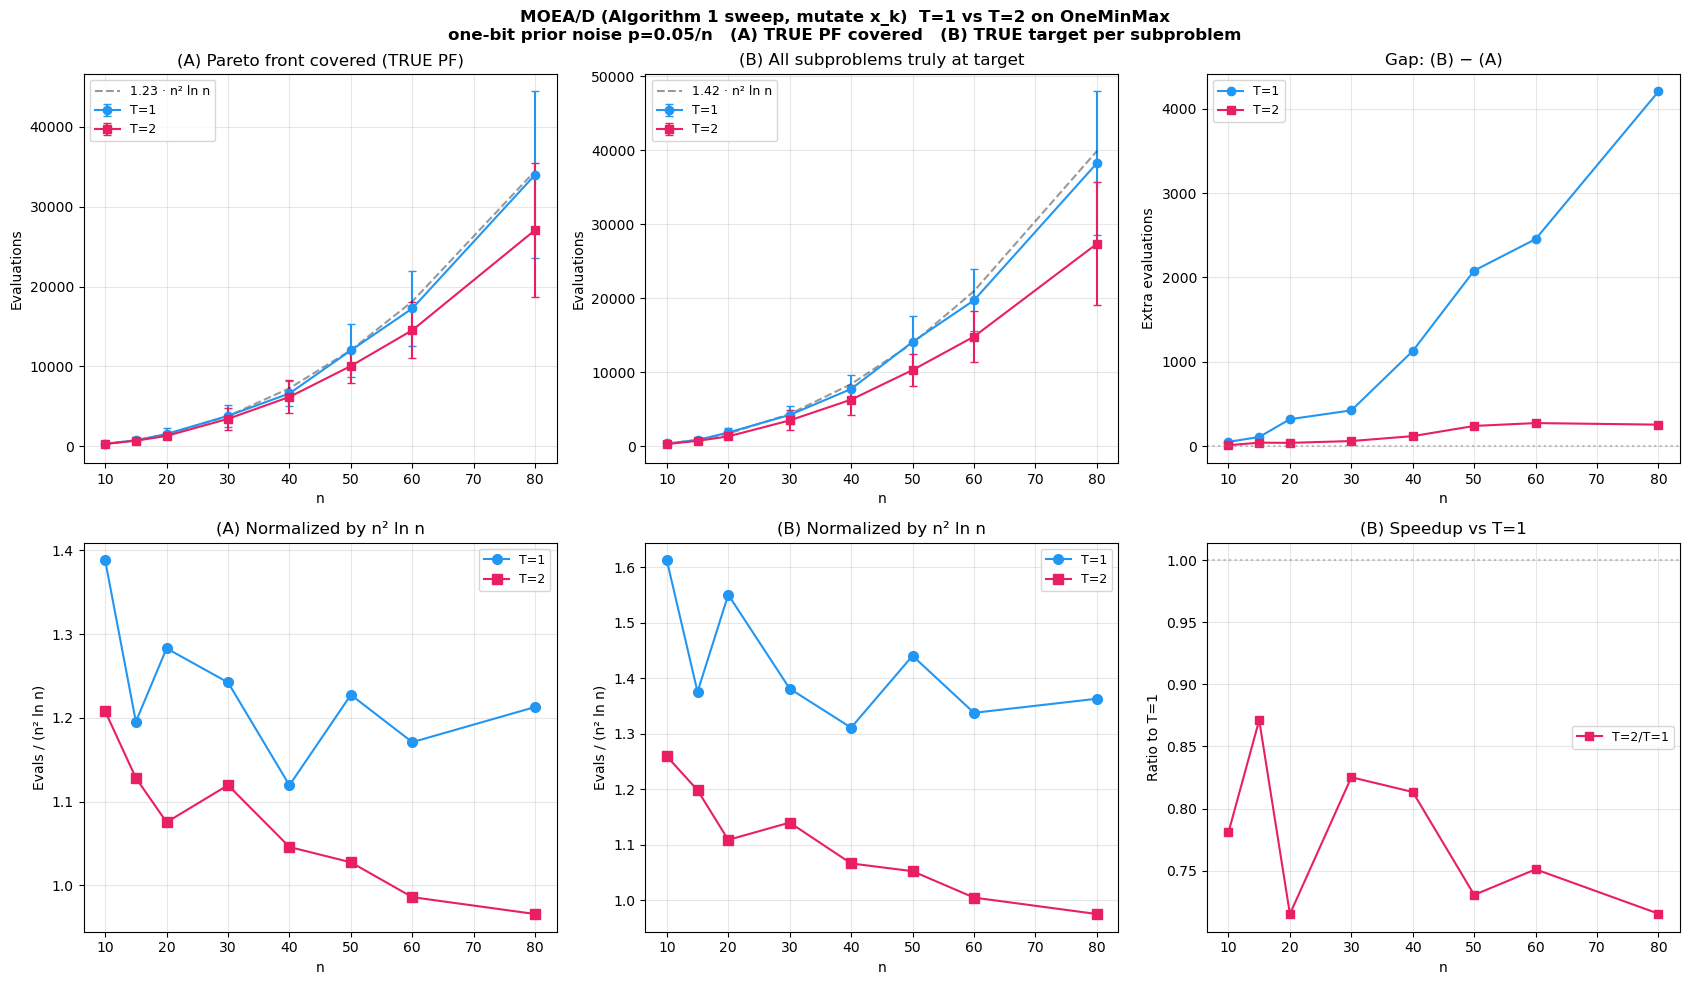


   n    T=1 OPT   T=1/(n²ln)    T=2 OPT   T=2/(n²ln)    T=2/T=1
--------------------------------------------------------------------------------------------
  10        371         1.61        290         1.26       0.78
  15        838         1.38        730         1.20       0.87
  20       1858         1.55       1329         1.11       0.72
  30       4228         1.38       3489         1.14       0.83
  40       7737         1.31       6293         1.07       0.81
  50      14088         1.44      10291         1.05       0.73
  60      19717         1.34      14809         1.00       0.75
  80      38226         1.36      27345         0.98       0.72


In [1]:
import numpy as np
import time
import matplotlib.pyplot as plt


# =========================
#  OneMinMax + one-bit prior noise
# =========================

def noisy_objs_oneminmax(x: np.ndarray, p: float, n: int, rng: np.random.Generator) -> tuple[int, int]:
    """
    One-bit prior noise: with prob p, flip a random bit BEFORE evaluation.
    Objectives (maximize): f1 = #ones, f2 = #zeros.
    """
    y = x
    if rng.random() < p:
        y = x.copy()
        j = int(rng.integers(n))
        y[j] ^= 1
    f1 = int(np.sum(y))
    return f1, n - f1


def dominates(a: tuple[int, int], b: tuple[int, int]) -> bool:
    """Maximization dominance on (f1,f2)."""
    return (a[0] >= b[0] and a[1] >= b[1]) and (a[0] > b[0] or a[1] > b[1])


# =========================
#  MOEA/D pieces (Algorithm 1 style)
# =========================

def weight_vector(k: int, N: int) -> tuple[float, float]:
    """
    Biobjective weights for subproblem k, k=0..N (N=H in the screenshot).
    lambda_k = (k/N, 1-k/N)
    """
    if N == 0:
        return (1.0, 0.0)
    a = k / N
    return (a, 1.0 - a)


def build_neighborhoods(N: int, T: int) -> list[list[int]]:
    """
    T closest subproblems by Euclidean distance of weight vectors.
    In 1D (k/N,1-k/N), nearest are adjacent and itself (distance 0).

    T=1: {k}
    T=2: {k, k-1} for k>0; for k=0 -> {0,1}; for k=N -> {N-1,N}
    """
    if T not in (1, 2):
        raise ValueError("This helper builds only T=1 or T=2 neighborhoods.")
    if N == 0:
        return [[0]]

    B = []
    for k in range(N + 1):
        if T == 1:
            B.append([k])
        else:  # T == 2
            if k == 0:
                B.append([0, 1])
            else:
                B.append([k - 1, k])
    return B


def decomp_tchebycheff_max(f1: int, f2: int, z1: int, z2: int, lam1: float, lam2: float) -> float:
    """
    MOEA/D Tchebycheff for MAXIMIZATION with reference point z* (ideal, componentwise max):
        F(x | k) = max( lam1*(z1 - f1(x)), lam2*(z2 - f2(x)) )
    Smaller is better.
    """
    return max(lam1 * (z1 - f1), lam2 * (z2 - f2))


def target_ones_for_k(k: int, N: int, n: int) -> int:
    """
    For F(x)=max(lam1*(n-f1), lam2*(n-f2)) with lam1=k/N, lam2=1-k/N and (f1,f2)=(ones,zeros),
    the minimizer along the PF is roughly ones ≈ lam1 * n.
    """
    if N == 0:
        return 0
    return int(round((k / N) * n))


# =========================
#  Algorithm 1 MOEA/D simulation (sweep + mutate x_k)
# =========================

def simulate_moead_algorithm1(
    n: int,
    N: int,          # this is H in the screenshot; population size = N+1
    p: float,
    T: int,
    max_evals: int | None = None,
    rng: np.random.Generator | None = None,
):
    """
    Matches the screenshot's Algorithm 1 structure:

      while not stop:
        for k=0..N:
          x_k' <- mutate(x_k)
          update each x_j in B_k if F_j(x_k') <= F_j(x_j)
          update z*
          update P (external nondominated set)

    Noise affects objective evaluations via one-bit prior noise.
    Stopping metrics we *measure* (not used by the algorithm):
      (A) PF covered by TRUE ones-counts among population
      (B) all subproblems truly at their target ones-count
    """
    if rng is None:
        rng = np.random.default_rng()
    if max_evals is None:
        max_evals = int(40 * n**2 * np.log(n + 1))

    B = build_neighborhoods(N, T)
    lambdas = [weight_vector(k, N) for k in range(N + 1)]
    targets = [target_ones_for_k(k, N, n) for k in range(N + 1)]

    # --- Initialize population X = {x_0,...,x_N}
    pop = [rng.integers(0, 2, size=n, dtype=np.int8) for _ in range(N + 1)]
    true_ones = np.array([int(np.sum(pop[k])) for k in range(N + 1)], dtype=int)

    # --- Compute noisy objective vectors for each x_k once (records)
    f1_hat = np.empty(N + 1, dtype=int)
    f2_hat = np.empty(N + 1, dtype=int)
    for k in range(N + 1):
        a, b = noisy_objs_oneminmax(pop[k], p, n, rng)
        f1_hat[k], f2_hat[k] = a, b

    total_evals = N + 1

    # --- Initialize reference point z* (componentwise max)
    z1 = int(np.max(f1_hat))
    z2 = int(np.max(f2_hat))

    # --- Initialize external nondominated set P (objective tuples only)
    P = set()
    for k in range(N + 1):
        P.add((int(f1_hat[k]), int(f2_hat[k])))

    # --- Performance bookkeeping (TRUE metrics)
    covered = set(true_ones.tolist())
    at_opt = np.array([true_ones[k] == targets[k] for k in range(N + 1)], dtype=bool)

    evals_pf = (N + 1) if (len(covered) == n + 1) else None
    evals_opt = (N + 1) if (np.all(at_opt)) else None

    # --- Main loop: sweep over subproblems
    while total_evals < max_evals:
        for k in range(N + 1):
            if total_evals >= max_evals:
                break

            # Step 5: x_k' by mutating x_k
            y = pop[k].copy()
            y[int(rng.integers(n))] ^= 1

            # evaluate once (noisy)
            fy1, fy2 = noisy_objs_oneminmax(y, p, n, rng)
            total_evals += 1

            # Step 6: update each solution in B_k with x_k'
            tfy1 = int(np.sum(y))  # true ones (for OUR metrics only)

            for j in B[k]:
                lam1, lam2 = lambdas[j]

                # compute decomposition values using CURRENT z*
                F_new = decomp_tchebycheff_max(fy1, fy2, z1, z2, lam1, lam2)
                F_old = decomp_tchebycheff_max(int(f1_hat[j]), int(f2_hat[j]), z1, z2, lam1, lam2)

                if F_new <= F_old:
                    pop[j] = y.copy()
                    f1_hat[j], f2_hat[j] = fy1, fy2
                    true_ones[j] = tfy1

                    covered.add(tfy1)
                    at_opt[j] = (tfy1 == targets[j])

            # Step 7: update z*
            if fy1 > z1:
                z1 = fy1
            if fy2 > z2:
                z2 = fy2

            # Step 8: update P (nondominated archive on (fy1,fy2))
            cand = (int(fy1), int(fy2))
            # if cand is dominated by something in P, do nothing
            if not any(dominates(pv, cand) for pv in P):
                # remove all points dominated by cand
                P = {pv for pv in P if not dominates(cand, pv)}
                P.add(cand)

            if evals_pf is None and len(covered) == n + 1:
                evals_pf = total_evals
            if evals_opt is None and np.all(at_opt):
                evals_opt = total_evals

            if evals_pf is not None and evals_opt is not None:
                break

        if evals_pf is not None and evals_opt is not None:
            break

    return {
        "evals_pf": evals_pf,
        "evals_opt": evals_opt,
        "converged_pf": (evals_pf is not None),
        "converged_opt": (evals_opt is not None),
        "total_evals": total_evals,
    }


# =========================
#  Experiment + plotting (T=1 vs T=2)
# =========================

def run(ns, p_factor, T, trials=30, seed=42):
    rng = np.random.default_rng(seed)
    results = {}
    for n in ns:
        p = p_factor / n
        pf_list, opt_list, cpf, copt = [], [], 0, 0
        print(f"T={T}, n={n:>4}, p={p:.4f} ... ", end="", flush=True)
        t0 = time.time()
        for _ in range(trials):
            r = simulate_moead_algorithm1(n=n, N=n, p=p, T=T, rng=rng)
            if r["converged_pf"]:
                pf_list.append(r["evals_pf"]); cpf += 1
            if r["converged_opt"]:
                opt_list.append(r["evals_opt"]); copt += 1
        mpf = np.mean(pf_list) if pf_list else float("nan")
        mopt = np.mean(opt_list) if opt_list else float("nan")
        print(f"PF {cpf}/{trials} ({mpf:.0f}), OPT {copt}/{trials} ({mopt:.0f}), {time.time()-t0:.1f}s")
        results[n] = {"pf": pf_list, "opt": opt_list, "cpf": cpf, "copt": copt, "trials": trials}
    return results


def extract(res, key, ns):
    me = np.array([np.mean(res[int(n)][key]) if res[int(n)][key]
                   else np.nan for n in ns])
    se = np.array([np.std(res[int(n)][key]) if res[int(n)][key]
                   else 0 for n in ns])
    return me, se


def make_plots(res1, res2, p_factor, ns_arr):
    th = ns_arr**2 * np.log(ns_arr)

    pf1, pf1_se = extract(res1, 'pf', ns_arr)
    pf2, pf2_se = extract(res2, 'pf', ns_arr)
    opt1, opt1_se = extract(res1, 'opt', ns_arr)
    opt2, opt2_se = extract(res2, 'opt', ns_arr)

    C = {'T1': '#2196F3', 'T2': '#E91E63'}

    fig, axes = plt.subplots(2, 3, figsize=(17, 10))

    # ── Row 1: raw evals ──
    ax = axes[0, 0]
    ax.errorbar(ns_arr, pf1, yerr=pf1_se, fmt='o-', color=C['T1'], capsize=3, label='T=1')
    ax.errorbar(ns_arr, pf2, yerr=pf2_se, fmt='s-', color=C['T2'], capsize=3, label='T=2')
    v = ~np.isnan(pf1)
    if np.any(v):
        c = np.nanmean(pf1[v] / th[v])
        ax.plot(ns_arr, c * th, 'k--', lw=1.5, alpha=0.4, label=f'{c:.2f} · n² ln n')
    ax.set_xlabel('n'); ax.set_ylabel('Evaluations')
    ax.set_title('(A) Pareto front covered (TRUE PF)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.errorbar(ns_arr, opt1, yerr=opt1_se, fmt='o-', color=C['T1'], capsize=3, label='T=1')
    ax.errorbar(ns_arr, opt2, yerr=opt2_se, fmt='s-', color=C['T2'], capsize=3, label='T=2')
    v = ~np.isnan(opt1)
    if np.any(v):
        c = np.nanmean(opt1[v] / th[v])
        ax.plot(ns_arr, c * th, 'k--', lw=1.5, alpha=0.4, label=f'{c:.2f} · n² ln n')
    ax.set_xlabel('n'); ax.set_ylabel('Evaluations')
    ax.set_title('(B) All subproblems truly at target')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[0, 2]
    gap1 = opt1 - pf1
    gap2 = opt2 - pf2
    for g, lbl, col, mk in [(gap1, 'T=1', C['T1'], 'o'), (gap2, 'T=2', C['T2'], 's')]:
        v = ~np.isnan(g)
        if np.any(v):
            ax.plot(ns_arr[v], g[v], f'{mk}-', color=col, label=lbl)
    ax.axhline(0, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('n'); ax.set_ylabel('Extra evaluations')
    ax.set_title('Gap: (B) − (A)')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    # ── Row 2: normalized by n^2 ln n ──
    ax = axes[1, 0]
    for vals, lbl, col, mk in [(pf1, 'T=1', C['T1'], 'o'), (pf2, 'T=2', C['T2'], 's')]:
        r = vals / th
        v = ~np.isnan(r)
        ax.plot(ns_arr[v], r[v], f'{mk}-', color=col, markersize=7, label=lbl)
    ax.set_xlabel('n'); ax.set_ylabel('Evals / (n² ln n)')
    ax.set_title('(A) Normalized by n² ln n')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    for vals, lbl, col, mk in [(opt1, 'T=1', C['T1'], 'o'), (opt2, 'T=2', C['T2'], 's')]:
        r = vals / th
        v = ~np.isnan(r)
        ax.plot(ns_arr[v], r[v], f'{mk}-', color=col, markersize=7, label=lbl)
    ax.set_xlabel('n'); ax.set_ylabel('Evals / (n² ln n)')
    ax.set_title('(B) Normalized by n² ln n')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[1, 2]
    both = ~np.isnan(opt2) & ~np.isnan(opt1)
    if np.any(both):
        ax.plot(ns_arr[both], opt2[both] / opt1[both], 's-', color=C['T2'], label='T=2/T=1')
    ax.axhline(1.0, color='gray', ls=':', alpha=0.5)
    ax.set_xlabel('n'); ax.set_ylabel('Ratio to T=1')
    ax.set_title('(B) Speedup vs T=1')
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    plt.suptitle(
        f'MOEA/D (Algorithm 1 sweep, mutate x_k)  T=1 vs T=2 on OneMinMax\n'
        f'one-bit prior noise p={p_factor}/n   (A) TRUE PF covered   (B) TRUE target per subproblem',
        fontsize=12, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    print("=" * 65)
    print("MOEA/D Algorithm 1 (sweep, mutate x_k) — T=1 vs T=2 on OneMinMax")
    print("=" * 65)

    p_factor = 0.05
    ns = [10, 15, 20, 30, 40, 50, 60, 80]
    trials = 30

    print(f"\n[T=1] p = {p_factor}/n")
    res1 = run(ns, p_factor, T=1, trials=trials, seed=42)

    print(f"\n[T=2] p = {p_factor}/n")
    res2 = run(ns, p_factor, T=2, trials=trials, seed=42)

    ns_arr = np.array(ns, dtype=float)
    make_plots(res1, res2, p_factor, ns_arr)

    # Summary table
    print("\n" + "=" * 92)
    print(f"{'n':>4} {'T=1 OPT':>10} {'T=1/(n²ln)':>12} {'T=2 OPT':>10} {'T=2/(n²ln)':>12} {'T=2/T=1':>10}")
    print("-" * 92)
    for n in ns:
        o1 = np.mean(res1[n]['opt']) if res1[n]['opt'] else float('nan')
        o2 = np.mean(res2[n]['opt']) if res2[n]['opt'] else float('nan')
        denom = (n**2 * np.log(n))
        ratio = (o2 / o1) if (np.isfinite(o1) and np.isfinite(o2) and o1 != 0) else float('nan')
        print(f"{n:>4} {o1:>10.0f} {o1/denom:>12.2f} {o2:>10.0f} {o2/denom:>12.2f} {ratio:>10.2f}")

MOEA/D Algorithm 1 — radius-1 neighborhood, z*=(n,n) init — OneMinMax
radius-1 neigh, n=  10, p=0.0050 ... PF 30/30 (158), OPT 30/30 (167), 0.1s
radius-1 neigh, n=  15, p=0.0033 ... PF 30/30 (343), OPT 30/30 (346), 0.1s
radius-1 neigh, n=  20, p=0.0025 ... PF 30/30 (634), OPT 30/30 (634), 0.2s
radius-1 neigh, n=  30, p=0.0017 ... PF 30/30 (1322), OPT 30/30 (1322), 0.6s
radius-1 neigh, n=  40, p=0.0013 ... PF 30/30 (2499), OPT 30/30 (2499), 1.1s
radius-1 neigh, n=  50, p=0.0010 ... PF 30/30 (4375), OPT 30/30 (4375), 1.9s
radius-1 neigh, n=  60, p=0.0008 ... PF 30/30 (6940), OPT 30/30 (6940), 3.5s
radius-1 neigh, n=  80, p=0.0006 ... PF 30/30 (13279), OPT 30/30 (13279), 7.3s


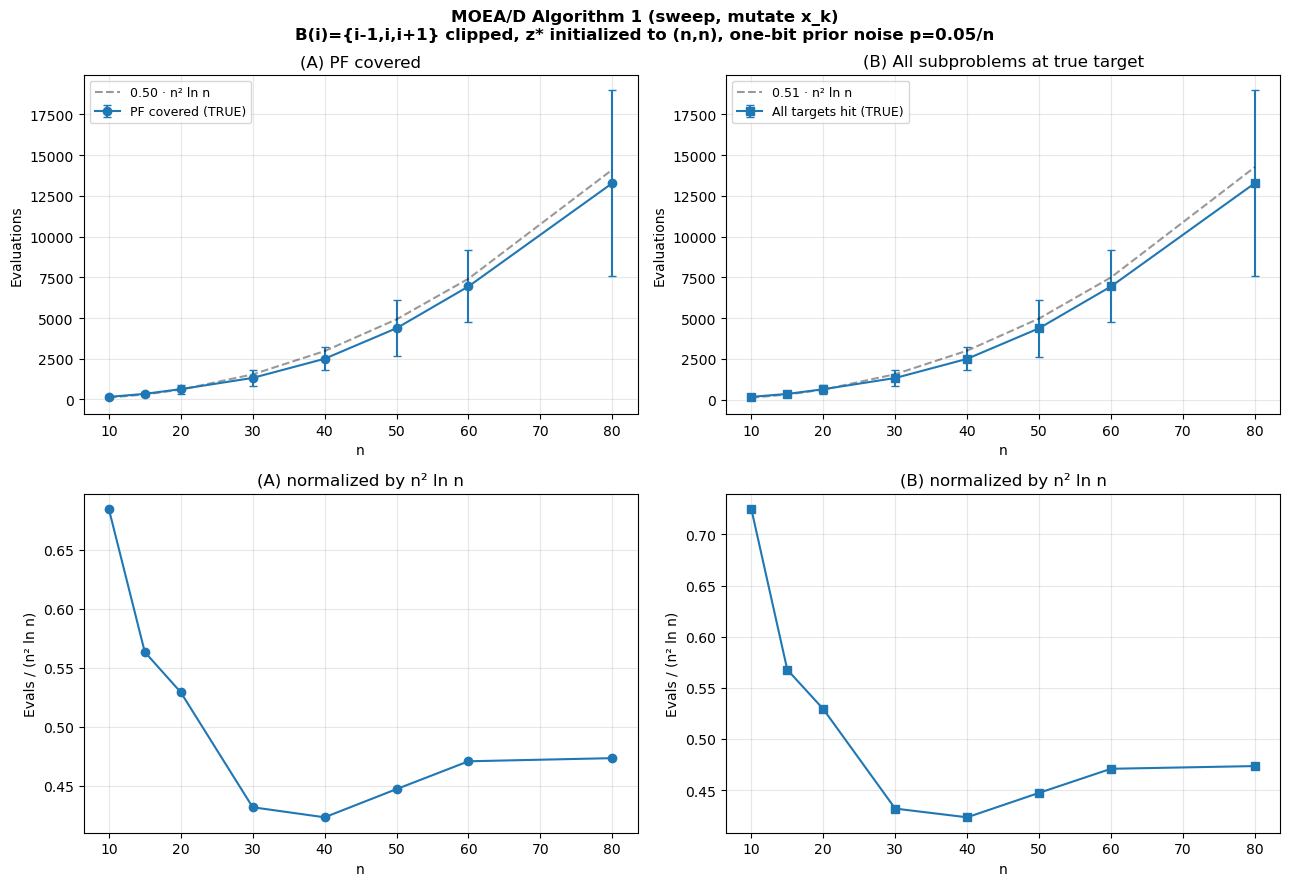


   n   OPT mean   OPT/(n²ln)    PF mean    PF/(n²ln)
----------------------------------------------------------------------
  10        167         0.72        158         0.68
  15        346         0.57        343         0.56
  20        634         0.53        634         0.53
  30       1322         0.43       1322         0.43
  40       2499         0.42       2499         0.42
  50       4375         0.45       4375         0.45
  60       6940         0.47       6940         0.47
  80      13279         0.47      13279         0.47


In [3]:
import numpy as np
import time
import matplotlib.pyplot as plt


# =========================
#  OneMinMax + one-bit prior noise
# =========================

def noisy_objs_oneminmax(x: np.ndarray, p: float, n: int, rng: np.random.Generator) -> tuple[int, int]:
    """
    One-bit prior noise: with prob p, flip a random bit BEFORE evaluation.
    Objectives (maximize): f1 = #ones, f2 = #zeros.
    """
    y = x
    if rng.random() < p:
        y = x.copy()
        j = int(rng.integers(n))
        y[j] ^= 1
    f1 = int(np.sum(y))
    return f1, n - f1


def dominates(a: tuple[int, int], b: tuple[int, int]) -> bool:
    """Maximization dominance on (f1,f2)."""
    return (a[0] >= b[0] and a[1] >= b[1]) and (a[0] > b[0] or a[1] > b[1])


# =========================
#  MOEA/D decomposition (Algorithm 1 style)
# =========================

def weight_vector(k: int, N: int) -> tuple[float, float]:
    """lambda_k = (k/N, 1-k/N) for k=0..N."""
    if N == 0:
        return (1.0, 0.0)
    a = k / N
    return (a, 1.0 - a)


def decomp_tchebycheff_max(f1: int, f2: int, z1: int, z2: int, lam1: float, lam2: float) -> float:
    """
    Tchebycheff for MAXIMIZATION with reference point z* (ideal, componentwise max):
        F(x|k) = max(lam1*(z1 - f1), lam2*(z2 - f2))
    Smaller is better.
    """
    return max(lam1 * (z1 - f1), lam2 * (z2 - f2))


def target_ones_for_k(k: int, N: int, n: int) -> int:
    """
    For OneMinMax with z*=(n,n) and lambda_k=(k/N,1-k/N),
    the minimizer on the true Pareto front has ones ≈ (k/N)*n.
    """
    if N == 0:
        return 0
    return int(round((k / N) * n))


# =========================
#  Neighborhood: B(i) = {i-1, i, i+1} clipped
# =========================

def build_neighborhoods_radius1(N: int) -> list[list[int]]:
    """
    B(i) = {i-1, i, i+1} ∩ {0,...,N}.
    """
    B = []
    for i in range(N + 1):
        neigh = []
        if i - 1 >= 0:
            neigh.append(i - 1)
        neigh.append(i)
        if i + 1 <= N:
            neigh.append(i + 1)
        B.append(neigh)
    return B


# =========================
#  MOEA/D Algorithm 1 simulation (sweep + mutate x_k) with:
#    - B(i) = {i-1,i,i+1} clipped
#    - z* initialized to optimal (n,n)
# =========================

def simulate_moead_alg1_radius1_zopt(
    n: int,
    N: int,                  # population size = N+1
    p: float,
    max_evals: int | None = None,
    rng: np.random.Generator | None = None,
):
    """
    Matches screenshot Algorithm 1 structure:

      while not stop:
        for k=0..N:
          x_k' <- mutate(x_k)
          update each x_j in B_k if F_j(x_k') <= F_j(x_j)
          update z*
          update P (external nondominated set)

    With:
      - B(k) = {k-1,k,k+1} clipped
      - z* initialized to the OPTIMAL ideal point (n,n)

    We measure two "true" milestones (not used by the algorithm):
      (A) TRUE PF covered: {0..n} appears as true ones-count among pop[0..N]
      (B) TRUE per-subproblem target hit: true_ones[k] == round((k/N)*n) for all k
    """
    if rng is None:
        rng = np.random.default_rng()
    if max_evals is None:
        max_evals = int(40 * n**2 * np.log(n + 1))

    B = build_neighborhoods_radius1(N)
    lambdas = [weight_vector(k, N) for k in range(N + 1)]
    targets = [target_ones_for_k(k, N, n) for k in range(N + 1)]

    # --- Initialize population X = {x_0,...,x_N}
    pop = [rng.integers(0, 2, size=n, dtype=np.int8) for _ in range(N + 1)]
    true_ones = np.array([int(np.sum(pop[k])) for k in range(N + 1)], dtype=int)

    # --- Initial noisy evaluations (fitness records)
    f1_hat = np.empty(N + 1, dtype=int)
    f2_hat = np.empty(N + 1, dtype=int)
    for k in range(N + 1):
        a, b = noisy_objs_oneminmax(pop[k], p, n, rng)
        f1_hat[k], f2_hat[k] = a, b

    total_evals = N + 1

    # --- Initialize z* to optimal ideal point
    z1, z2 = n, n

    # --- External nondominated archive P on noisy objective vectors
    P = set((int(f1_hat[k]), int(f2_hat[k])) for k in range(N + 1))

    # --- TRUE progress metrics
    covered = set(true_ones.tolist())
    at_opt = np.array([true_ones[k] == targets[k] for k in range(N + 1)], dtype=bool)

    evals_pf = (N + 1) if (len(covered) == n + 1) else None
    evals_opt = (N + 1) if (np.all(at_opt)) else None

    # --- Main loop: sweep
    while total_evals < max_evals:
        for k in range(N + 1):
            if total_evals >= max_evals:
                break

            # Step 5: mutate x_k to produce candidate
            y = pop[k].copy()
            y[int(rng.integers(n))] ^= 1

            # one noisy evaluation
            fy1, fy2 = noisy_objs_oneminmax(y, p, n, rng)
            total_evals += 1

            tfy1 = int(np.sum(y))  # TRUE ones-count for our metrics

            # Step 6: update each solution in B_k with x_k'
            for j in B[k]:
                lam1, lam2 = lambdas[j]
                F_new = decomp_tchebycheff_max(fy1, fy2, z1, z2, lam1, lam2)
                F_old = decomp_tchebycheff_max(int(f1_hat[j]), int(f2_hat[j]), z1, z2, lam1, lam2)

                if F_new <= F_old:
                    pop[j] = y.copy()
                    f1_hat[j], f2_hat[j] = fy1, fy2
                    true_ones[j] = tfy1

                    covered.add(tfy1)
                    at_opt[j] = (tfy1 == targets[j])

            # Step 7: update z* (will never change since z*=(n,n) is maximal)
            # kept for fidelity with the pseudocode
            # z1 = max(z1, fy1); z2 = max(z2, fy2)

            # Step 8: update P
            cand = (int(fy1), int(fy2))
            if not any(dominates(pv, cand) for pv in P):
                P = {pv for pv in P if not dominates(cand, pv)}
                P.add(cand)

            if evals_pf is None and len(covered) == n + 1:
                evals_pf = total_evals
            if evals_opt is None and np.all(at_opt):
                evals_opt = total_evals

            if evals_pf is not None and evals_opt is not None:
                break

        if evals_pf is not None and evals_opt is not None:
            break

    return {
        "evals_pf": evals_pf,
        "evals_opt": evals_opt,
        "converged_pf": (evals_pf is not None),
        "converged_opt": (evals_opt is not None),
        "total_evals": total_evals,
    }


# =========================
#  Experiment + plotting
# =========================

def run(ns, p_factor, trials=30, seed=42):
    rng = np.random.default_rng(seed)
    results = {}
    for n in ns:
        p = p_factor / n
        pf_list, opt_list, cpf, copt = [], [], 0, 0
        print(f"radius-1 neigh, n={n:>4}, p={p:.4f} ... ", end="", flush=True)
        t0 = time.time()
        for _ in range(trials):
            r = simulate_moead_alg1_radius1_zopt(n=n, N=n, p=p, rng=rng)
            if r["converged_pf"]:
                pf_list.append(r["evals_pf"]); cpf += 1
            if r["converged_opt"]:
                opt_list.append(r["evals_opt"]); copt += 1
        mpf = np.mean(pf_list) if pf_list else float("nan")
        mopt = np.mean(opt_list) if opt_list else float("nan")
        print(f"PF {cpf}/{trials} ({mpf:.0f}), OPT {copt}/{trials} ({mopt:.0f}), {time.time()-t0:.1f}s")
        results[n] = {"pf": pf_list, "opt": opt_list, "cpf": cpf, "copt": copt, "trials": trials}
    return results


def extract(res, key, ns):
    me = np.array([np.mean(res[int(n)][key]) if res[int(n)][key] else np.nan for n in ns])
    se = np.array([np.std(res[int(n)][key]) if res[int(n)][key] else 0.0 for n in ns])
    return me, se


def make_plots(res, p_factor, ns_arr):
    th = ns_arr**2 * np.log(ns_arr)

    pf, pf_se = extract(res, "pf", ns_arr)
    opt, opt_se = extract(res, "opt", ns_arr)

    fig, axes = plt.subplots(2, 2, figsize=(13, 9))

    ax = axes[0, 0]
    ax.errorbar(ns_arr, pf, yerr=pf_se, fmt="o-", capsize=3, label="PF covered (TRUE)")
    v = ~np.isnan(pf)
    if np.any(v):
        c = np.nanmean(pf[v] / th[v])
        ax.plot(ns_arr, c * th, "k--", lw=1.5, alpha=0.4, label=f"{c:.2f} · n² ln n")
    ax.set_xlabel("n"); ax.set_ylabel("Evaluations")
    ax.set_title("(A) PF covered")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.errorbar(ns_arr, opt, yerr=opt_se, fmt="s-", capsize=3, label="All targets hit (TRUE)")
    v = ~np.isnan(opt)
    if np.any(v):
        c = np.nanmean(opt[v] / th[v])
        ax.plot(ns_arr, c * th, "k--", lw=1.5, alpha=0.4, label=f"{c:.2f} · n² ln n")
    ax.set_xlabel("n"); ax.set_ylabel("Evaluations")
    ax.set_title("(B) All subproblems at true target")
    ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    r = pf / th
    v = ~np.isnan(r)
    ax.plot(ns_arr[v], r[v], "o-")
    ax.set_xlabel("n"); ax.set_ylabel("Evals / (n² ln n)")
    ax.set_title("(A) normalized by n² ln n")
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    r = opt / th
    v = ~np.isnan(r)
    ax.plot(ns_arr[v], r[v], "s-")
    ax.set_xlabel("n"); ax.set_ylabel("Evals / (n² ln n)")
    ax.set_title("(B) normalized by n² ln n")
    ax.grid(True, alpha=0.3)

    plt.suptitle(
        f"MOEA/D Algorithm 1 (sweep, mutate x_k)\n"
        f"B(i)={{i-1,i,i+1}} clipped, z* initialized to (n,n), one-bit prior noise p={p_factor}/n",
        fontsize=12, fontweight="bold"
    )
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    print("=" * 78)
    print("MOEA/D Algorithm 1 — radius-1 neighborhood, z*=(n,n) init — OneMinMax")
    print("=" * 78)

    p_factor = 0.05
    ns = [10, 15, 20, 30, 40, 50, 60, 80,100, 120]
    trials = 30

    res = run(ns, p_factor, trials=trials, seed=42)

    ns_arr = np.array(ns, dtype=float)
    make_plots(res, p_factor, ns_arr)

    print("\n" + "=" * 70)
    print(f"{'n':>4} {'OPT mean':>10} {'OPT/(n²ln)':>12} {'PF mean':>10} {'PF/(n²ln)':>12}")
    print("-" * 70)
    for n in ns:
        o = np.mean(res[n]["opt"]) if res[n]["opt"] else float("nan")
        a = np.mean(res[n]["pf"]) if res[n]["pf"] else float("nan")
        denom = n**2 * np.log(n)
        print(f"{n:>4} {o:>10.0f} {o/denom:>12.2f} {a:>10.0f} {a/denom:>12.2f}")